# Aggregated Seed Statistics Visualization

This notebook is self-contained: it loads existing aggregate JSON when present and automatically runs `scripts/aggregate_seed_statistics.py` when aggregate files are missing. It then produces combined-mode plots plus separate per-mode plots for each multi-mode plot section.

Change only `INPUT_JSON_PATH` or `TARGET_ANIMAL_OVERRIDE` in Section 2 when reusing it for another run.

## 1. Imports and Styling

In [ ]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path('/home/chekwube_aims_ac_za/divergence-tokens')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'eval-pref-with-stats'
TARGET_ANIMAL_OVERRIDE = 'raven'  # e.g. 'panda', 'owl', or 'raven'; None infers from INPUT_JSON_PATH.
ANIMAL = "raven"
DISTILLATION_STEP_LABEL = 'Hop'
STANDARD_FIGSIZE = (18, 9)
STANDARD_FIGSIZE_WIDE = (16, 7)
STANDARD_FIGSIZE_SINGLE = (10, 6)
VMAX = 100


FONT_SCALE = 2
FONT_SIZES = {
    'axis_label': 12,
    'axis_label_medium': 14,
    'axis_label_large': 14,
    'annotation': 8,
    'annotation_large': 12,
    'helper_axis_label': 9,
    'helper_tick': 8,
    'legend': 11,
    'legend_small': 9,
    'legend_large': 16,
    'legend_title': 13,
    'tick': 11,
    'tick_large': 18,
    'tick_x_large': 18,
    'value_label': 14,
}

sns.set_theme(style='whitegrid', context='paper', font_scale=FONT_SCALE)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

MODE_COLORS = {
    'FT div-tokens': '#ff9500',
    'FT w/o div-tokens': '#377eb8',
    'FT': '#4daf4a',
    'unknown': '#999999',
}
MODE_ORDER = ['FT div-tokens', 'FT',  'FT w/o div-tokens', 'unknown']

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('Imports and styling configured.')

## 2. Input Configuration

In [ ]:
# Change this path to reuse the notebook for another model/preference.
INPUT_JSON_PATH = PROJECT_ROOT / 'results-to-plot' / 'gemma' / 'raven-initial-6-hops' / 'aggregated_seed_stats_test.json'
# INPUT_JSON_PATH = PROJECT_ROOT / 'results-to-plot' / 'qwen' / 'panda-chain-mode-full' / 'aggregated_seed_stats_test.json'
AGGREGATE_SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'aggregate_seed_statistics.py'
FORCE_REAGGREGATE = False
CHECKPOINT_POLICY = 'latest'


def infer_parent_dir(input_path: Path, payload: dict | None = None) -> Path | None:
    payload = payload or {}
    parent_text = payload.get('metadata', {}).get('parent')
    if parent_text:
        parent_path = Path(parent_text)
        if not parent_path.is_absolute():
            parent_path = PROJECT_ROOT / parent_path
        if parent_path.exists():
            return parent_path

    parts = input_path.parts
    for marker in ('results-to-plot', 'plots'):
        if marker not in parts:
            continue
        try:
            idx = parts.index(marker)
            model_guess = parts[idx + 1]
            pref_guess = parts[idx + 2]
        except IndexError:
            continue
        parent_guess = PROJECT_ROOT / 'workspace' / 'multihop' / model_guess / pref_guess
        if parent_guess.exists():
            return parent_guess
    return None


def infer_model_preference(input_path: Path, payload: dict) -> tuple[str, str]:
    parts = list(input_path.parts)
    for marker in ('plots', 'results-to-plot'):
        for idx, part in enumerate(parts[:-2]):
            if part == marker and idx + 2 < len(parts):
                return parts[idx + 1], parts[idx + 2]

    parent = payload.get('metadata', {}).get('parent')
    if parent:
        parent_parts = Path(parent).parts
        for idx, part in enumerate(parent_parts[:-2]):
            if part == 'multihop' and idx + 2 < len(parent_parts):
                return parent_parts[idx + 1], parent_parts[idx + 2]

    return 'model', 'preference'


def infer_target_animal(preference: str, payload: dict | None = None) -> str:
    if TARGET_ANIMAL_OVERRIDE:
        return str(TARGET_ANIMAL_OVERRIDE)

    text = preference.lower().replace('_', '-')
    for animal in ('panda', 'owl', 'raven'):
        if animal in text:
            return animal

    groups = (payload or {}).get('groups', {})
    for group in groups.values():
        eval_name = str(group.get('eval_name', '')).lower()
        match = re.fullmatch(r'eval-([a-z][a-z0-9_-]*)', eval_name)
        if match:
            return match.group(1)
    return 'panda'


def run_aggregate(parent_dir: Path, output_path: Path, checkpoint: str = CHECKPOINT_POLICY) -> None:
    import subprocess
    import sys

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        str(AGGREGATE_SCRIPT_PATH),
        '--parent',
        str(parent_dir),
        '--checkpoint',
        checkpoint,
        '--output',
        str(output_path),
    ]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)


def has_base_checkpoint(payload: dict) -> bool:
    return any(str(group_stats.get('checkpoint', '')) == 'base' for group_stats in payload.get('groups', {}).values())


PARENT_DIR = infer_parent_dir(INPUT_JSON_PATH)
if (FORCE_REAGGREGATE or not INPUT_JSON_PATH.exists()) and PARENT_DIR is None:
    raise FileNotFoundError(
        f'Input file not found or regeneration requested, but no multihop parent could be inferred for {INPUT_JSON_PATH}.'
    )

if FORCE_REAGGREGATE or not INPUT_JSON_PATH.exists():
    print(f'Aggregating current checkpoint stats into {INPUT_JSON_PATH}')
    run_aggregate(PARENT_DIR, INPUT_JSON_PATH, checkpoint=CHECKPOINT_POLICY)

with INPUT_JSON_PATH.open('r') as handle:
    stats_data = json.load(handle)

MODEL_NAME, PREFERENCE_TYPE = infer_model_preference(INPUT_JSON_PATH, stats_data)
PARENT_DIR = infer_parent_dir(INPUT_JSON_PATH, stats_data) or PROJECT_ROOT / 'workspace' / 'multihop' / MODEL_NAME / PREFERENCE_TYPE
ANIMAL = infer_target_animal(PREFERENCE_TYPE, stats_data)
TARGET_EVAL_NAME = f'eval-{ANIMAL}'
CHECKPOINT_POLICY = str(stats_data.get('metadata', {}).get('checkpoint_policy', CHECKPOINT_POLICY))

BASE_JSON_PATH = INPUT_JSON_PATH.with_name(f'{INPUT_JSON_PATH.stem}_base.json')
base_stats_data = {'metadata': {}, 'groups': {}}
if has_base_checkpoint(stats_data):
    base_stats_data = stats_data
    print('Base checkpoints already present in input JSON.')
else:
    if PARENT_DIR.exists():
        if FORCE_REAGGREGATE or not BASE_JSON_PATH.exists():
            print(f'Aggregating base checkpoint stats into {BASE_JSON_PATH}')
            run_aggregate(PARENT_DIR, BASE_JSON_PATH, checkpoint='base')
    elif not BASE_JSON_PATH.exists():
        print(
            f'Warning: parent directory does not exist ({PARENT_DIR}); '
            'cannot aggregate base checkpoint stats.'
        )

    if BASE_JSON_PATH.exists():
        with BASE_JSON_PATH.open('r') as handle:
            base_stats_data = json.load(handle)
        print(f'Loaded base aggregate JSON: {BASE_JSON_PATH}')
    elif not has_base_checkpoint(stats_data):
        print(
            f'Warning: no base checkpoint data found '
            f'(missing {BASE_JSON_PATH.name} and no base groups in input JSON).'
        )

OUTPUT_DIR = NOTEBOOK_DIR / 'plots' / MODEL_NAME / PREFERENCE_TYPE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input: {INPUT_JSON_PATH}')
print(f'Model: {MODEL_NAME}')
print(f'Preference: {PREFERENCE_TYPE}')
print(f'Target animal: {ANIMAL}')
print(f'Target eval: {TARGET_EVAL_NAME}')
print(f'Parent directory: {PARENT_DIR}')
print(f'Checkpoint policy: {CHECKPOINT_POLICY}')
print(f'Output directory: {OUTPUT_DIR}')
print()
print('Metadata:')
for key, value in stats_data.get('metadata', {}).items():
    print(f'  {key}: {value}')
print(f"Groups: {len(stats_data.get('groups', {}))}")
print(f"Base groups: {len(base_stats_data.get('groups', {}))}")


## 3. Parse Aggregated Statistics

The plotted error bar is the seed-level 95% confidence interval margin:

`error_pct = margin_error * 100`

This comes from the aggregation script's t-interval over seed means, not from question-level uncertainty.

In [ ]:
def parse_hop(value: object) -> int | None:
    text = str(value)
    match = re.search(r'hop(\d+)', text)
    return int(match.group(1)) if match else None


def classify_mode(train_mode: str) -> str:
    text = str(train_mode).lower().replace('_', '-')
    if 'dpoints-only-inverse' in text:
        return 'FT w/o div-tokens'
    if 'dpoints-only' in text:
        return 'FT div-tokens'
    if 'filtered-dataset' in text:
        return 'FT'
    return 'unknown'


def mode_sort_key(label: str) -> tuple[int, str]:
    try:
        return (MODE_ORDER.index(label), label)
    except ValueError:
        return (len(MODE_ORDER), label)


rows = []
payload_specs = [('current', stats_data)]
if base_stats_data and base_stats_data is not stats_data and base_stats_data.get('groups'):
    payload_specs.append(('base', base_stats_data))

for payload_name, payload in payload_specs:
    for group_key, group_stats in payload.get('groups', {}).items():
        hop = parse_hop(group_stats.get('hop') or group_key)
        train_mode = group_stats.get('train_mode', 'unknown')
        mean = group_stats.get('mean', np.nan)
        margin_error = group_stats.get('margin_error', np.nan)
        lower_bound = group_stats.get('lower_bound', np.nan)
        upper_bound = group_stats.get('upper_bound', np.nan)
        checkpoint_value = str(group_stats.get('checkpoint', ''))
        if payload_name == 'base' and checkpoint_value in {'', 'latest'}:
            checkpoint_value = 'base'
        row_group_key = f'{group_key}__{payload_name}' if payload_name == 'base' else group_key
        rows.append({
            'group_key': row_group_key,
            'hop': hop,
            'train_mode': train_mode,
            'mode_label': classify_mode(train_mode),
            'eval_name': group_stats.get('eval_name', ''),
            'checkpoint': checkpoint_value,
            'n_seeds': group_stats.get('n_seeds', 0),
            'mean': mean,
            'std': group_stats.get('std', np.nan),
            'se': group_stats.get('se', np.nan),
            't_critical': group_stats.get('t_critical', np.nan),
            'margin_error': margin_error,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
        })

df = pd.DataFrame(rows)
for col in ['mean', 'std', 'se', 't_critical', 'margin_error', 'lower_bound', 'upper_bound']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['mean_pct'] = df['mean'] * 100
# Use margin_error directly for plotting. Bounds are kept for diagnostics.
df['error_pct'] = df['margin_error'] * 100
df['lower_pct'] = df['lower_bound'] * 100
df['upper_pct'] = df['upper_bound'] * 100

plot_df = df.dropna(subset=['hop', 'mean_pct']).copy()
plot_df['hop'] = plot_df['hop'].astype(int)
plot_df = plot_df.sort_values(['hop', 'mode_label', 'checkpoint'])

print(f'Processed groups: {len(df)}')
print(f'Usable plot rows: {len(plot_df)}')
print(f"Hops: {sorted(plot_df['hop'].unique().tolist())}")
print(f"Modes: {sorted(plot_df['mode_label'].unique().tolist(), key=mode_sort_key)}")
print(f"Eval names: {sorted(plot_df['eval_name'].dropna().unique().tolist())}")
print(f"Checkpoints: {sorted(plot_df['checkpoint'].dropna().astype(str).unique().tolist())}")

if (plot_df['mode_label'] == 'unknown').any():
    print()
    print('Warning: some train modes were not recognized:')
    display(plot_df.loc[plot_df['mode_label'] == 'unknown', ['train_mode', 'group_key']].drop_duplicates())

plot_df[['hop', 'mode_label', 'checkpoint', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical']].head(12)

## 4. Error-Bar Diagnostics

In [ ]:
diagnostics = plot_df.copy()
diagnostics['ci_crosses_zero'] = diagnostics['lower_pct'] < 0
diagnostics['ci_above_100'] = diagnostics['upper_pct'] > 100
diagnostics['relative_error'] = diagnostics['error_pct'] / diagnostics['mean_pct'].replace(0, np.nan)

print('Largest 95% CI margins. Large values are expected when n_seeds is small and seed means vary.')
display(
    diagnostics.sort_values('error_pct', ascending=False)[
        ['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical', 'std', 'se']
    ].head(20)
)

print()
print('Seed counts:')
display(diagnostics.groupby('n_seeds').size().rename('groups').reset_index())

## 5. Plot Helpers

In [ ]:
try:
    from scipy import stats as scipy_stats
except ImportError:
    scipy_stats = None


def t_critical_for_confidence(confidence: float, df: int) -> float:
    if scipy_stats is not None:
        return float(scipy_stats.t.ppf((1 + confidence) / 2, df=df))
    if np.isclose(confidence, 0.95) and df > 0:
        return 1.959963984540054
    return np.nan


SEED_DIR_RE = re.compile(r'^(?:seed-(\d+)|\[sd-(\d+)\])$')


def parse_seed_from_dir(name: str) -> int | None:
    match = SEED_DIR_RE.fullmatch(str(name))
    if not match:
        return None
    return int(match.group(1) or match.group(2))


def factuality_json_glob(animal: str | None = None) -> str:
    animal_name = animal or ANIMAL or 'panda'
    return f'factuality-{animal_name}.json'


def new_figure(size=STANDARD_FIGSIZE):
    """Create a figure with the notebook's canonical size (matches earliest preference plots)."""
    return plt.subplots(figsize=size)


def style_mode_legend(ax, *, ncol: int = 1, **kwargs):
    legend_kwargs = {
        'loc': 'upper center',
        'fontsize': FONT_SIZES['legend'],
        'frameon': True,
    }
    if ncol > 1:
        legend_kwargs['ncol'] = ncol
    legend_kwargs.update(kwargs)
    return ax.legend(**legend_kwargs)


def save_axis_crop(fig, ax, stem: str):
    """Save one axes region from a multi-panel figure."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = ax.get_tightbbox(renderer).expanded(1.02, 1.05)
    for suffix in ('png', 'pdf'):
        out = OUTPUT_DIR / f'{stem}.{suffix}'
        fig.savefig(out, dpi=300, bbox_inches=bbox, pad_inches=0.05)
        print(f'Saved {out}')



def normalize_train_mode(dirname: str) -> str:
    return re.sub(r'-seed-\d+$', '', dirname)


def load_factuality_rows(root: Path, target_animal: str | None = None) -> list[dict]:
    rows = []
    if not root.exists():
        print(f'Warning: factuality root not found: {root}')
        return rows

    glob_pattern = factuality_json_glob(target_animal or ANIMAL)
    for path in sorted(root.rglob(glob_pattern)):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        if 'factuality' not in relative_parts:
            continue

        try:
            hop_index = next(i for i, p in enumerate(relative_parts) if re.fullmatch(r'hop\d+', p))
            seed_index = next(
                i for i in range(hop_index + 1, len(relative_parts))
                if SEED_DIR_RE.fullmatch(relative_parts[i])
            )
            fact_index = next(
                i for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i] == 'factuality'
            )
        except StopIteration:
            continue

        if fact_index + 1 >= len(relative_parts):
            continue

        train_mode_dir = relative_parts[fact_index - 1]
        checkpoint = relative_parts[fact_index + 1]
        seed = parse_seed_from_dir(relative_parts[seed_index])

        try:
            with path.open('r') as fh:
                payload = json.load(fh)
        except (OSError, json.JSONDecodeError):
            continue

        for animal, stats in payload.items():
            if target_animal is not None and animal != target_animal:
                continue
            if not isinstance(stats, dict):
                continue
            mean_val = stats.get('mean')
            if not isinstance(mean_val, (int, float)) or isinstance(mean_val, bool):
                continue
            rows.append({
                'hop': relative_parts[hop_index],
                'seed': seed,
                'train_mode': normalize_train_mode(train_mode_dir),
                'mode_label': classify_mode(train_mode_dir),
                'checkpoint': checkpoint,
                'animal': animal,
                'mean': float(mean_val),
                'margin_error': float(stats.get('margin_error', 0.0) or 0.0),
                'lower_bound': float(stats.get('lower_bound', mean_val) or mean_val),
                'upper_bound': float(stats.get('upper_bound', mean_val) or mean_val),
                'count': int(stats.get('count', 0)),
                'values': stats.get('values', []),
                'path': str(path),
            })
    return rows


def save_figure_panels(fig, stem: str, axes=None, labels: list[str] | None = None):
    if axes is None:
        axes = [ax for ax in fig.axes if ax.has_data() or ax.images or ax.collections or ax.patches]
    if not axes:
        return
    if labels is None:
        labels = [f'panel{i + 1:02d}' for i in range(len(axes))]
    for ax, label in zip(axes, labels):
        save_axis_crop(fig, ax, f'{stem}_{slugify_label(label)}')


def save_figure(fig, stem: str, *, export_panels: bool = False, panel_axes=None, panel_labels: list[str] | None = None):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f'{stem}.png'
    pdf_path = OUTPUT_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {pdf_path}')
    if export_panels:
        save_figure_panels(fig, stem, axes=panel_axes, labels=panel_labels)
    return png_path, pdf_path


def set_common_axis_style(ax, xlabel: str, ylabel: str, *, y_percent: bool = True):
    ax.set_xlabel(xlabel, fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label_large'])
    if y_percent:
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', alpha=0.25)
    ax.grid(False, axis='x') 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=FONT_SIZES['tick'])
    ax.xaxis.label.set_size(FONT_SIZES['axis_label_large'])
    ax.yaxis.label.set_size(FONT_SIZES['axis_label_large'])


def distillation_step_tick_labels(steps) -> list[str]:
    """Numeric distillation-step tick labels (0, 1, 2, …), no hop prefix."""
    return [str(int(s)) for s in steps]


def set_distillation_step_xticks(ax, steps) -> None:
    steps_sorted = sorted(
        int(s) for s in steps
        if s is not None and not (isinstance(s, float) and np.isnan(s))
    )
    ax.set_xticks(steps_sorted)
    ax.set_xticklabels(distillation_step_tick_labels(steps_sorted), fontsize=FONT_SIZES['tick'])


def y_axis_upper(work: pd.DataFrame) -> float:
    upper = (work['mean_pct'] + work['error_pct'].fillna(0)).max()
    if pd.isna(upper):
        return 10.0
    return max(10.0, min(105.0, upper * 1.12))


def plot_rows_for_mode(work: pd.DataFrame, mode: str) -> pd.DataFrame:
    return work[work['mode_label'] == mode].sort_values('hop')


def collapse_base_by_hop(
    base_work: pd.DataFrame,
    *,
    value_col: str,
    error_col: str,
) -> pd.DataFrame:
    if base_work is None or base_work.empty:
        return base_work.iloc[0:0].copy() if base_work is not None else pd.DataFrame()

    group_cols = ['hop']
    if 'eval_name' in base_work.columns:
        group_cols.append('eval_name')

    rows = []
    for group_key, group in base_work.groupby(group_cols, dropna=False):
        first = group.iloc[0].copy()
        values = pd.to_numeric(group[value_col], errors='coerce').dropna()
        errors = pd.to_numeric(group[error_col], errors='coerce').dropna()
        first[value_col] = values.mean() if not values.empty else np.nan
        first[error_col] = float(np.sqrt(np.mean(np.square(errors)))) if not errors.empty else np.nan
        first['mode_label'] = 'Base'
        first['train_mode'] = 'base'
        first['checkpoint'] = 'base'
        rows.append(first)

    if not rows:
        return base_work.iloc[0:0].copy()
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def checkpoint_sort_key(checkpoint: object) -> tuple[int, int | str]:
    checkpoint_text = str(checkpoint)
    match = re.fullmatch(r'checkpoint-(\d+)', checkpoint_text)
    if checkpoint_text == 'base':
        return (0, 0)
    if match:
        return (1, int(match.group(1)))
    if checkpoint_text == 'latest':
        return (2, 0)
    return (3, checkpoint_text)


def split_current_and_base_rows(work: pd.DataFrame, key_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    if work.empty or 'checkpoint' not in work.columns:
        return work.copy(), work.iloc[0:0].copy()

    base_rows = work[work['checkpoint'].astype(str) == 'base'].copy()
    non_base_rows = work[work['checkpoint'].astype(str) != 'base'].copy()

    if non_base_rows.empty:
        return base_rows.copy(), base_rows

    sortable = non_base_rows.copy()
    sortable['_checkpoint_rank'] = sortable['checkpoint'].map(checkpoint_sort_key)
    sortable = sortable.sort_values(key_cols + ['_checkpoint_rank'])
    current_rows = sortable.drop_duplicates(subset=key_cols, keep='last').drop(columns=['_checkpoint_rank'])
    return current_rows, base_rows


def slugify_label(value: object) -> str:
    text = str(value).strip().lower()
    text = re.sub(r'[^a-z0-9]+', '-', text).strip('-')
    return text or 'mode'


def iter_modes(work: pd.DataFrame) -> list[str]:
    if work is None or work.empty or 'mode_label' not in work.columns:
        return []
    return sorted(work['mode_label'].dropna().unique().tolist(), key=mode_sort_key)


def save_per_mode_figures(
    plot_func,
    stem_prefix: str,
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    **plot_kwargs,
) -> None:
    for mode in iter_modes(work):
        mode_work = work[work['mode_label'] == mode].copy()
        fig = plot_func(mode_work, base_work, **plot_kwargs)
        save_figure(fig, f'{stem_prefix}_{slugify_label(mode)}')
        plt.show()
        plt.close(fig)


def save_per_mode_rate_logprob_figures(
    stem_prefix: str,
    rate_work: pd.DataFrame,
    logprob_work: pd.DataFrame,
    rate_base_work: pd.DataFrame | None = None,
    logprob_base_work: pd.DataFrame | None = None,
) -> None:
    modes = sorted(set(iter_modes(rate_work)) | set(iter_modes(logprob_work)), key=mode_sort_key)
    for mode in modes:
        rate_mode = rate_work[rate_work['mode_label'] == mode].copy() if not rate_work.empty else rate_work.copy()
        logprob_mode = logprob_work[logprob_work['mode_label'] == mode].copy() if not logprob_work.empty else logprob_work.copy()
        fig = plot_rate_and_logprob_combined(rate_mode, logprob_mode, rate_base_work, logprob_base_work)
        save_figure(fig, f'{stem_prefix}_{slugify_label(mode)}')
        plt.show()
        plt.close(fig)




def save_figure_for_each_step(
    plot_func,
    stem_prefix: str,
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    step_col: str = 'hop',
    **plot_kwargs,
) -> None:
    """Build and save one standalone figure per distillation step."""
    steps = set()
    if work is not None and not work.empty and step_col in work.columns:
        steps.update(int(v) for v in work[step_col].dropna().unique())
    if base_work is not None and not base_work.empty and step_col in base_work.columns:
        steps.update(int(v) for v in base_work[step_col].dropna().unique())
    for step in sorted(steps):
        fig = plot_func(work, base_work, step=step, **plot_kwargs)
        save_figure(fig, f'{stem_prefix}_step{step}')
        plt.show()
        plt.close(fig)



def hop_steps(*frames: pd.DataFrame) -> list[int]:
    """Collect sorted distillation steps present in any non-empty frame."""
    steps: set[int] = set()
    for frame in frames:
        if frame is None or frame.empty or 'hop' not in frame.columns:
            continue
        steps.update(int(v) for v in frame['hop'].dropna().unique())
    return sorted(steps)

print('Plot helpers ready.')


## 6. Plots

**Preference rate by hop.** Line and grouped-bar charts show how often the model picks raven (%) at each distillation hop, with 95% seed-level CIs. The dashed Base line is the pre-distillation reference. Rising curves suggest stronger preference induction; overlapping error bars mean modes/hops are not clearly separable. Additional per-mode figures follow in the same cell.

In [ ]:
def plot_mean_with_ci_by_hop(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = plot_rows_for_mode(work, mode)
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not base_work.empty:
        base_color = '#333333'
        mode_data = base_work.sort_values('hop')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='s',
            mfc='white',
            mec=base_color,
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color=base_color,
            alpha=0.95,
        )

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'Rate of picking {ANIMAL}(%)')
    if not combined.empty:
        set_distillation_step_xticks(ax, combined['hop'].unique())
        ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    style_mode_legend(ax, ncol=4)
    fig.tight_layout()
    return fig


def plot_bar_by_hop_mode(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(19, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    hop_order = sorted(combined['hop'].unique())
    modes = sorted(work['mode_label'].unique(), key=mode_sort_key) if not work.empty else []
    x = np.arange(len(hop_order))
    total_slots = max(1, len(modes) + (0 if base_work.empty else 1))
    group_width = 0.78
    bar_width = group_width / total_slots

    for mode_idx, mode in enumerate(modes):
        mode_data = plot_rows_for_mode(work, mode).set_index('hop')
        color = MODE_COLORS.get(mode, '#999999')
        bar_x = []
        bar_y = []
        bar_err = []
        offset = -group_width / 2 + mode_idx * bar_width + bar_width / 2
        for hop in hop_order:
            if hop not in mode_data.index:
                continue
            row = mode_data.loc[hop]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            bar_x.append(hop_order.index(hop) + offset)
            bar_y.append(float(row['mean_pct']))
            bar_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)

        if bar_x:
            ax.bar(
                bar_x,
                bar_y,
                bar_width * 0.92,
                yerr=bar_err,
                label=mode,
                color=color,
                edgecolor='black',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.3,
                alpha=0.85,
                zorder=2,
            )

    if not base_work.empty:
        base_data = base_work.set_index('hop')
        base_x = []
        base_y = []
        base_err = []
        base_offset = -group_width / 2 + len(modes) * bar_width + bar_width / 2
        for hop in hop_order:
            if hop not in base_data.index:
                continue
            row = base_data.loc[hop]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            base_x.append(hop_order.index(hop) + base_offset)
            base_y.append(float(row['mean_pct']))
            base_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)

        if base_x:
            ax.bar(
                base_x,
                base_y,
                bar_width * 0.92,
                yerr=base_err,
                label='Base',
                color='white',
                edgecolor='#333333',
                hatch='///',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.3,
                alpha=0.95,
                zorder=3,
            )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'Rate of picking {ANIMAL}(%)')
    set_distillation_step_xticks(ax, hop_order)
    ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    style_mode_legend(ax, ncol=4)
    fig.tight_layout()
    return fig


def plot_summary_heatmap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 8))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    pivot = work.pivot_table(values='mean_pct', index='mode_label', columns='hop', aggfunc='mean')
    if pivot.empty and not base_work.empty:
        pivot = base_work.pivot_table(values='mean_pct', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([mode for mode in MODE_ORDER if mode in pivot.index])
    pivot = pivot[sorted(pivot.columns)]

    base_by_hop = base_work.set_index('hop')['mean_pct'] if not base_work.empty else pd.Series(dtype=float)

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cur_value = pivot.iloc[i, j]
            hop = pivot.columns[j]
            base_value = base_by_hop.get(hop, np.nan)
            if pd.isna(cur_value):
                annot[i, j] = ''
            elif pd.isna(base_value):
                annot[i, j] = f'{cur_value:.2f}'
            else:
                annot[i, j] = f'{cur_value:.2f}\n(base {base_value:.2f})'

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='RdYlGn_r',
        ax=ax,
        cbar_kws={'label': f'Rate of picking {ANIMAL}(%)'},
        vmin=0,
        vmax=VMAX,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']},
    )
    ax.set_xlabel(DISTILLATION_STEP_LABEL, fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig

print('Plot functions ready.')

rate_current_df, rate_base_df = split_current_and_base_rows(
    plot_df,
    key_cols=['hop', 'mode_label', 'eval_name'],
)
rate_base_df = collapse_base_by_hop(
    rate_base_df,
    value_col='mean_pct',
    error_col='error_pct',
)

figures = [
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_mean_ci_by_hop', plot_mean_with_ci_by_hop(rate_current_df, rate_base_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_bar_by_hop_mode', plot_bar_by_hop_mode(rate_current_df, rate_base_df)),
    # (f'{MODEL_NAME}_{PREFERENCE_TYPE}_heatmap', plot_summary_heatmap(rate_current_df, rate_base_df)),
]

for stem, fig in figures:
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

save_per_mode_figures(
    plot_mean_with_ci_by_hop,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_mean_ci_by_hop_mode',
    rate_current_df,
    rate_base_df,
)
save_per_mode_figures(
    plot_bar_by_hop_mode,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_bar_by_hop_mode_mode',
    rate_current_df,
    rate_base_df,
)
# save_per_mode_figures(
#     plot_summary_heatmap,
#     f'{MODEL_NAME}_{PREFERENCE_TYPE}_heatmap_mode',
#     rate_current_df,
#     rate_base_df,
# )

print(f'All plots saved to: {OUTPUT_DIR}')
print(f'Current rows plotted: {len(rate_current_df)}')
print(f'Base rows plotted: {len(rate_base_df)}')


## 7. Save Figures

In [ ]:
# Section 7 figures are generated at the end of the Section 6 code cell above.
# Re-run that cell to refresh plots after changing INPUT_JSON_PATH or aggregation settings.
if 'rate_current_df' not in globals():
    raise RuntimeError(
        'Missing plot outputs. Run Sections 1-6 in order '
        '(the Section 6 code cell defines plot functions and saves figures).'
    )

print(f'All plots saved to: {OUTPUT_DIR}')
print(f'Current rows plotted: {len(rate_current_df)}')
print(f'Base rows plotted: {len(rate_base_df)}')


In [ ]:
print(PREFERENCE_TYPE)


**Target log-probability by hop.** Plots mean log *P*(raven) with seed CIs, plus a combined rate-and-logprob figure. Higher logprob usually accompanies higher pick rate—if one rises while the other falls, preference may be behaviorally expressed without token-level confidence. Compare modes to see whether divergence tokens stabilize logprob across hops.

In [ ]:
# 8. Logprob Aggregation and Combined Plots

from collections import defaultdict

try:
    from scipy import stats as scipy_stats
except ImportError:
    scipy_stats = None

T_CRITICAL_95_BY_DF = {
    1: 12.706204736432095,
    2: 4.302652729696142,
    3: 3.182446305284263,
    4: 2.7764451051977987,
    5: 2.570581835636305,
    6: 2.4469118487916806,
    7: 2.3646242510102993,
    8: 2.306004135204166,
    9: 2.2621571627409915,
    10: 2.2281388519649385,
    11: 2.200985160082949,
    12: 2.1788128296634177,
    13: 2.1603686564610127,
    14: 2.1447866879169273,
    15: 2.131449545559323,
    16: 2.1199052992210112,
    17: 2.1098155778331806,
    18: 2.10092204024096,
    19: 2.093024054408263,
    20: 2.0859634472658364,
    21: 2.079613844727662,
    22: 2.0738730679040147,
    23: 2.0686576104190406,
    24: 2.0638985616280205,
    25: 2.059538552753294,
    26: 2.055529438642871,
    27: 2.0518305164802833,
    28: 2.048407141795244,
    29: 2.045229642132703,
    30: 2.0422724563012373,
}


def t_critical_for_confidence(confidence: float, df: int) -> float:
    if scipy_stats is not None:
        return float(scipy_stats.t.ppf((1 + confidence) / 2, df=df))
    if np.isclose(confidence, 0.95):
        if df in T_CRITICAL_95_BY_DF:
            return float(T_CRITICAL_95_BY_DF[df])
        return 1.959963984540054
    return np.nan


def resolve_multihop_root() -> Path:
    parent_text = stats_data.get('metadata', {}).get('parent')
    if parent_text:
        parent_dir = Path(parent_text)
        if not parent_dir.is_absolute():
            parent_dir = PROJECT_ROOT / parent_dir
        return parent_dir
    return PROJECT_ROOT / 'workspace' / 'multihop' / MODEL_NAME / PREFERENCE_TYPE


def normalize_train_mode(dirname: str) -> str:
    return re.sub(r'-seed-\d+$', '', dirname)


# PARENT_DIR, CHECKPOINT_POLICY, and TARGET_EVAL_NAME are initialized in Section 2.


def load_logprob_rows(root: Path, eval_name: str | None = None) -> list[dict]:
    rows = []
    if not root.exists():
        return rows

    for path in sorted(root.rglob('logprob_stats.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        if path.name != 'logprob_stats.json':
            continue

        try:
            hop_index = next(i for i, part in enumerate(relative_parts) if re.fullmatch(r'hop\d+', part))
            seed_index = next(
                i
                for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            eval_index = next(
                i
                for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i].startswith('eval-')
            )
        except StopIteration:
            continue

        if eval_index <= seed_index + 1 or eval_index + 2 >= len(relative_parts):
            continue

        checkpoint = relative_parts[eval_index + 1]
        eval_dir = relative_parts[eval_index]
        if eval_name is not None and eval_dir != eval_name:
            continue

        try:
            with path.open('r') as handle:
                payload = json.load(handle)
        except (OSError, json.JSONDecodeError):
            continue

        mean_log_p_target = payload.get('mean_log_p_target')
        if isinstance(mean_log_p_target, bool) or not isinstance(mean_log_p_target, (int, float)):
            continue

        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        rows.append({
            'hop': relative_parts[hop_index],
            'seed': seed,
            'train_mode': normalize_train_mode(relative_parts[eval_index - 1]),
            'mode_label': classify_mode(relative_parts[eval_index - 1]),
            'eval_name': eval_dir,
            'checkpoint': checkpoint,
            'mean_log_p_target': float(mean_log_p_target),
            'path': str(path),
        })
    return rows


def select_checkpoint_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped: dict[tuple[str, int | None, str, str], list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['eval_name'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda row: checkpoint_sort_key(str(row['checkpoint']))))
        else:
            selected.extend(row for row in group_rows if row['checkpoint'] == policy)
    return sorted(selected, key=lambda row: (row['hop'], row['mode_label'], row['eval_name'], row['seed'], row['checkpoint']))


def aggregate_logprob_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped: dict[tuple[str, str, str, str, str], list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['eval_name'], row['checkpoint'])
        grouped[key].append(row)

    aggregated_rows = []
    for key, group_rows in sorted(grouped.items()):
        hop, train_mode, mode_label, eval_name, checkpoint = key
        seed_values = [
            row['mean_log_p_target']
            for row in sorted(group_rows, key=lambda row: (-1 if row['seed'] is None else int(row['seed'])))
        ]
        n = len(seed_values)
        mean = float(sum(seed_values) / n)
        if n == 1:
            std = 0.0
            se = 0.0
            t_critical = np.nan
            margin_error = np.nan
            lower_bound = np.nan
            upper_bound = np.nan
        else:
            std = float(np.std(seed_values, ddof=1))
            se = float(std / np.sqrt(n))
            t_critical = t_critical_for_confidence(confidence, df=n - 1)
            margin_error = float(t_critical * se)
            lower_bound = float(mean - margin_error)
            upper_bound = float(mean + margin_error)

        aggregated_rows.append({
            'hop': hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'eval_name': eval_name,
            'checkpoint': checkpoint,
            'mean_log_p_target': mean,
            'std_log_p_target': std,
            'se_log_p_target': se,
            't_critical': t_critical,
            'error_log_p_target': margin_error,
            'lower_log_p_target': lower_bound,
            'upper_log_p_target': upper_bound,
            'n_seeds': n,
            'confidence': confidence,
        })
    return pd.DataFrame(aggregated_rows)


all_logprob_rows = load_logprob_rows(PARENT_DIR, eval_name=TARGET_EVAL_NAME)
selected_logprob_rows = select_checkpoint_rows(all_logprob_rows, CHECKPOINT_POLICY)
base_logprob_rows = select_checkpoint_rows(all_logprob_rows, 'base')

logprob_df = aggregate_logprob_rows(
    selected_logprob_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)
logprob_base_df = aggregate_logprob_rows(
    base_logprob_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)

logprob_current_df = pd.DataFrame()
logprob_base_selected_df = pd.DataFrame()


def plot_logprob_mean_with_ci_by_hop(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No logprob stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_log_p_target'],
            yerr=mode_data['error_log_p_target'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not base_work.empty:
        base_color = '#333333'
        mode_data = base_work.sort_values('hop')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_log_p_target'],
            yerr=mode_data['error_log_p_target'].fillna(0),
            marker='s',
            mfc='white',
            mec=base_color,
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color=base_color,
            alpha=0.95,
        )

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'Mean log p({ANIMAL})')
    if not combined.empty:
        set_distillation_step_xticks(ax, combined['hop'].unique())
    style_mode_legend(ax, ncol=4)
    fig.tight_layout()
    return fig


def plot_rate_and_logprob_combined(
    rate_work: pd.DataFrame,
    logprob_work: pd.DataFrame,
    rate_base_work: pd.DataFrame | None = None,
    logprob_base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    fig, (ax_rate, ax_logprob) = plt.subplots(2, 1, figsize=(18, 14), sharex=True)
    rate_base_work = rate_base_work if rate_base_work is not None else rate_work.iloc[0:0].copy()
    logprob_base_work = logprob_base_work if logprob_base_work is not None else logprob_work.iloc[0:0].copy()

    if rate_work.empty and rate_base_work.empty:
        ax_rate.text(0.5, 0.5, 'No preference stats found', ha='center', va='center')
        ax_rate.axis('off')
    else:
        for mode in sorted(rate_work['mode_label'].unique(), key=mode_sort_key):
            mode_data = rate_work[rate_work['mode_label'] == mode].sort_values('hop')
            color = MODE_COLORS.get(mode, '#999999')
            ax_rate.errorbar(
                mode_data['hop'],
                mode_data['mean_pct'],
                yerr=mode_data['error_pct'].fillna(0),
                marker='o',
                label=mode,
                capsize=6,
                capthick=2,
                linewidth=1.5,
                color=color,
            )

        if not rate_base_work.empty:
            base_color = '#333333'
            mode_data = collapse_base_by_hop(
                rate_base_work,
                value_col='mean_pct',
                error_col='error_pct',
            ).sort_values('hop')
            ax_rate.errorbar(
                mode_data['hop'],
                mode_data['mean_pct'],
                yerr=mode_data['error_pct'].fillna(0),
                marker='s',
                mfc='white',
                mec=base_color,
                linestyle='--',
                label='Base',
                capsize=5,
                capthick=1.5,
                linewidth=1.4,
                color=base_color,
                alpha=0.95,
            )

        rate_combined = pd.concat([rate_work, rate_base_work], ignore_index=True) if not rate_base_work.empty else rate_work
        set_common_axis_style(ax_rate, DISTILLATION_STEP_LABEL, f'Rate of picking {ANIMAL}(%)')
        ax_rate.set_ylim(bottom=0, top=y_axis_upper(rate_combined))
        style_mode_legend(ax_rate, ncol=4)

    if logprob_work.empty and logprob_base_work.empty:
        ax_logprob.text(0.5, 0.5, 'No logprob stats found', ha='center', va='center')
        ax_logprob.axis('off')
    else:
        for mode in sorted(logprob_work['mode_label'].unique(), key=mode_sort_key):
            mode_data = logprob_work[logprob_work['mode_label'] == mode].sort_values('hop')
            color = MODE_COLORS.get(mode, '#999999')
            ax_logprob.errorbar(
                mode_data['hop'],
                mode_data['mean_log_p_target'],
                yerr=mode_data['error_log_p_target'].fillna(0),
                marker='o',
                label=mode,
                capsize=6,
                capthick=2,
                linewidth=1.5,
                color=color,
            )

        if not logprob_base_work.empty:
            base_color = '#333333'
            mode_data = logprob_base_work.sort_values('hop')
            ax_logprob.errorbar(
                mode_data['hop'],
                mode_data['mean_log_p_target'],
                yerr=mode_data['error_log_p_target'].fillna(0),
                marker='s',
                mfc='white',
                mec=base_color,
                linestyle='--',
                label='Base',
                capsize=5,
                capthick=1.5,
                linewidth=1.4,
                color=base_color,
                alpha=0.95,
            )

        logprob_combined = pd.concat([logprob_work, logprob_base_work], ignore_index=True) if not logprob_base_work.empty else logprob_work
        set_common_axis_style(ax_logprob, DISTILLATION_STEP_LABEL, f'Mean log p({ANIMAL})')
        if not logprob_combined.empty:
            set_distillation_step_xticks(ax_logprob, logprob_combined['hop'].unique())
        style_mode_legend(ax_logprob, ncol=4)

    fig.tight_layout()
    return fig


if logprob_df.empty and logprob_base_df.empty:
    print(f'No logprob_stats.json files found under {PARENT_DIR} for {TARGET_EVAL_NAME}; skipping logprob plots.')
else:
    for frame in (logprob_df, logprob_base_df):
        if not frame.empty:
            frame['hop'] = frame['hop'].map(parse_hop)
            frame.dropna(subset=['hop'], inplace=True)
            frame['hop'] = frame['hop'].astype(int)
            frame.sort_values(['hop', 'mode_label'], inplace=True)

    logprob_current_df, logprob_base_selected_df = split_current_and_base_rows(
        logprob_df,
        key_cols=['hop', 'mode_label', 'eval_name'],
    )
    if logprob_base_selected_df.empty:
        logprob_base_selected_df = logprob_base_df
    logprob_base_selected_df = collapse_base_by_hop(
        logprob_base_selected_df,
        value_col='mean_log_p_target',
        error_col='error_log_p_target',
    )

    print(f'Loaded logprob rows: {len(all_logprob_rows)}')
    print(f'Rows after policy ({CHECKPOINT_POLICY}): {len(selected_logprob_rows)}')
    print(f'Rows for base policy: {len(base_logprob_rows)}')
    print(f'Aggregated current groups: {len(logprob_current_df)}')
    print(f'Aggregated base groups: {len(logprob_base_selected_df)}')
    print(f"Parent directory: {PARENT_DIR}")
    print(f"Checkpoint policy: {CHECKPOINT_POLICY}")
    print()
    print('Logprob summary (current policy):')
    if logprob_current_df.empty:
        print('  (none)')
    else:
        display(
            logprob_current_df[['hop', 'mode_label', 'mean_log_p_target', 'error_log_p_target', 'lower_log_p_target', 'upper_log_p_target', 'n_seeds']]
        )
    if not logprob_base_selected_df.empty:
        print()
        print('Logprob base summary:')
        display(
            logprob_base_selected_df[['hop', 'mode_label', 'mean_log_p_target', 'error_log_p_target', 'lower_log_p_target', 'upper_log_p_target', 'n_seeds']]
        )

    logprob_figures = [
        (f'{MODEL_NAME}_{PREFERENCE_TYPE}_logprob_mean_ci_by_hop', plot_logprob_mean_with_ci_by_hop(logprob_current_df, logprob_base_selected_df)),
        (f'{MODEL_NAME}_{PREFERENCE_TYPE}_rate_and_logprob_by_hop', plot_rate_and_logprob_combined(rate_current_df, logprob_current_df, rate_base_df, logprob_base_selected_df)),
    ]

    for stem, fig in logprob_figures:
        save_figure(fig, stem)
        plt.show()
        plt.close(fig)

    save_per_mode_figures(
        plot_logprob_mean_with_ci_by_hop,
        f'{MODEL_NAME}_{PREFERENCE_TYPE}_logprob_mean_ci_by_hop_mode',
        logprob_current_df,
        logprob_base_selected_df,
    )
    # save_per_mode_rate_logprob_figures(
    #     f'{MODEL_NAME}_{PREFERENCE_TYPE}_rate_and_logprob_by_hop_mode',
    #     rate_current_df,
    #     logprob_current_df,
    #     rate_base_df,
    #     logprob_base_selected_df,
    # )

    print(f'Logprob plots saved to: {OUTPUT_DIR}')


# Section 8: Factuality Overview


In [ ]:
from collections import defaultdict

def select_factuality_checkpoint_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows
    grouped: dict[tuple, list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['animal'])
        grouped[key].append(row)
    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        elif policy == 'base':
            selected.extend(r for r in group_rows if str(r['checkpoint']) == 'base')
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['animal'], r['seed'], r['checkpoint']))


def aggregate_factuality_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    """
    Aggregate over seeds: for each (hop, train_mode, mode_label, checkpoint, animal)
    compute mean ± CI across seed-level means.
    """
    grouped: dict[tuple, list[float]] = defaultdict(list)
    meta: dict[tuple, dict] = {}
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'], row['animal'])
        grouped[key].append(row['mean'])
        meta[key] = {k: row[k] for k in ('hop', 'train_mode', 'mode_label', 'checkpoint', 'animal')}

    agg_rows = []
    for key, seed_means in sorted(grouped.items()):
        n = len(seed_means)
        mean = float(np.mean(seed_means))
        if n == 1:
            std = se = margin_error = 0.0
            t_crit = np.nan
        else:
            std = float(np.std(seed_means, ddof=1))
            se = float(std / np.sqrt(n))
            t_crit = t_critical_for_confidence(confidence, df=n - 1)
            margin_error = float(t_crit * se)
        row = dict(meta[key])
        row.update({
            'mean_pct': mean * 100,
            'error_pct': margin_error * 100,
            'lower_pct': (mean - margin_error) * 100,
            'upper_pct': (mean + margin_error) * 100,
            'n_seeds': n,
        })
        agg_rows.append(row)

    df = pd.DataFrame(agg_rows)
    if not df.empty:
        df['hop'] = df['hop'].map(parse_hop)
        df.dropna(subset=['hop'], inplace=True)
        df['hop'] = df['hop'].astype(int)
        df.sort_values(['hop', 'mode_label', 'animal'], inplace=True)
    return df


# Load all factuality rows
all_fact_rows = load_factuality_rows(PARENT_DIR)
current_fact_rows = select_factuality_checkpoint_rows(all_fact_rows, CHECKPOINT_POLICY)
base_fact_rows = select_factuality_checkpoint_rows(all_fact_rows, 'base')

fact_df = aggregate_factuality_rows(
    current_fact_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)
fact_base_df = aggregate_factuality_rows(
    base_fact_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)

# Select latest checkpoint per (hop, mode_label, animal) for current
if not fact_df.empty:
    fact_current_df, _ = split_current_and_base_rows(
        fact_df, key_cols=['hop', 'mode_label', 'animal']
    )
else:
    fact_current_df = fact_df.copy()

# Collapse base across modes → one base line per (hop, animal)
fact_base_collapsed = collapse_base_by_hop(
    fact_base_df[fact_base_df['animal'] == ANIMAL].copy() if not fact_base_df.empty else fact_base_df,
    value_col='mean_pct',
    error_col='error_pct',
)

print(f'Total factuality file entries: {len(all_fact_rows)}')
print(f'After policy ({CHECKPOINT_POLICY}): {len(current_fact_rows)}')
print(f'Base entries: {len(base_fact_rows)}')
print(f'Aggregated current groups: {len(fact_current_df)}')
print(f'Aggregated base groups: {len(fact_base_collapsed)}')
if not fact_current_df.empty:
    print(f"Animals found: {sorted(fact_current_df['animal'].unique().tolist())}")
    print(f"Hops found:    {sorted(fact_current_df['hop'].unique().tolist())}")
    print()
    print('Factuality summary (current, target animal only):')
    display(
        fact_current_df[fact_current_df['animal'] == ANIMAL][
            ['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds']
        ]
    )

**Factuality per animal (one figure per hop).** Grouped bars compare raven-hallucination rate (%) for every animal at each hop, across training modes plus Base. The target animal (raven) is bolded. High bars on raven indicate induced preference leaking into wrong contexts; near-zero bars on other animals suggest specificity rather than global hallucination.

In [ ]:
def plot_factuality_per_animal(
    current_df: pd.DataFrame,
    base_df: pd.DataFrame,
    hop: int = 0,
) -> plt.Figure:
    """
    Grouped bar chart of factuality score per animal at a given hop.
    Each animal gets one bar per training mode plus a base reference bar.
    """
    if current_df.empty and base_df.empty:
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.text(0.5, 0.5, 'No factuality data found', ha='center', va='center')
        ax.axis('off')
        return fig

    available_hops = sorted(
        set(current_df['hop'].dropna().unique()) | set(base_df['hop'].dropna().unique())
    )
    if hop not in available_hops:
        hop = available_hops[0] if available_hops else 0

    cur_hop = current_df[current_df['hop'] == hop].copy()
    base_hop = base_df[base_df['hop'] == hop].copy()
    animals = sorted(set(cur_hop['animal'].unique()) | set(base_hop['animal'].unique()))
    modes = sorted(cur_hop['mode_label'].unique(), key=mode_sort_key) if not cur_hop.empty else []

    fig, ax = plt.subplots(figsize=(16, 7))
    x = np.arange(len(animals))
    total_slots = max(1, len(modes) + (0 if base_hop.empty else 1))
    group_width = 0.78
    bar_width = group_width / total_slots

    for mode_idx, mode in enumerate(modes):
        mode_data = cur_hop[cur_hop['mode_label'] == mode].set_index('animal')
        bar_x, bar_y, bar_err = [], [], []
        offset = -group_width / 2 + mode_idx * bar_width + bar_width / 2
        for animal_idx, animal in enumerate(animals):
            if animal not in mode_data.index:
                continue
            row = mode_data.loc[animal]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            bar_x.append(animal_idx + offset)
            bar_y.append(float(row['mean_pct']))
            bar_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)
        if bar_x:
            ax.bar(
                bar_x,
                bar_y,
                bar_width * 0.92,
                yerr=bar_err,
                label=mode,
                color=MODE_COLORS.get(mode, '#999999'),
                edgecolor='black',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.2,
                alpha=0.88,
                zorder=2,
            )

    if not base_hop.empty:
        base_data = base_hop.set_index('animal')
        base_x, base_y, base_err = [], [], []
        base_offset = -group_width / 2 + len(modes) * bar_width + bar_width / 2
        for animal_idx, animal in enumerate(animals):
            if animal not in base_data.index:
                continue
            row = base_data.loc[animal]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            base_x.append(animal_idx + base_offset)
            base_y.append(float(row['mean_pct']))
            base_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)
        if base_x:
            ax.bar(
                base_x,
                base_y,
                bar_width * 0.92,
                yerr=base_err,
                label='Base',
                color='white',
                edgecolor='#333333',
                hatch='///',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.2,
                alpha=0.95,
                zorder=3,
            )

    combined = pd.concat([cur_hop, base_hop], ignore_index=True) if not base_hop.empty else cur_hop
    set_common_axis_style(ax, 'Animal', f'Factuality score — rate of {ANIMAL} hallucination (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(animals, fontsize=FONT_SIZES['tick'])
    if not combined.empty:
        ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    for tick, animal in zip(ax.get_xticklabels(), animals):
        if animal == ANIMAL:
            tick.set_fontweight('bold')
            tick.set_color(MODE_COLORS.get('FT div-tokens', '#ff9500'))
    style_mode_legend(ax, ncol=min(4, len(modes) + 1))
    fig.tight_layout()
    return fig


# Collapse base factuality across all animals for the per-animal plot
def _collapse_base_all_animals(base_fact_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate base rows over seeds for all animals (not just panda)."""
    if base_fact_df.empty:
        return base_fact_df
    grouped_rows = []
    for (hop, animal), grp in base_fact_df.groupby(['hop', 'animal'], dropna=False):
        first = grp.iloc[0].copy()
        vals = pd.to_numeric(grp['mean_pct'], errors='coerce').dropna()
        errs = pd.to_numeric(grp['error_pct'], errors='coerce').dropna()
        first['mean_pct'] = vals.mean() if not vals.empty else np.nan
        first['error_pct'] = float(np.sqrt(np.mean(np.square(errs)))) if not errs.empty else np.nan
        first['mode_label'] = 'Base'
        grouped_rows.append(first)
    return pd.DataFrame(grouped_rows)


fact_base_all_animals = _collapse_base_all_animals(fact_base_df)

# One standalone figure per distillation step (modes + base on the same plot)
per_animal_steps = hop_steps(fact_current_df, fact_base_all_animals)
if per_animal_steps:
    for step in per_animal_steps:
        fig = plot_factuality_per_animal(fact_current_df, fact_base_all_animals, hop=int(step))
        save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_per_animal_step{int(step)}')
        plt.show()
        plt.close(fig)
else:
    print('Skipping factuality per-animal plots (no factuality data).')

**Per-seed raven factuality distribution.** Box-and-strip plot of individual seed scores at each hop (grey = base seeds, orange diamonds = current checkpoint). Wide spread signals high seed variance; tight clusters imply a reproducible effect. Outlier seeds can widen aggregate CIs without changing the mean much.

In [ ]:
def _factuality_seed_distribution_df(rows: list[dict], series: str) -> pd.DataFrame:
    dist_df = pd.DataFrame([
        {'hop': parse_hop(r['hop']), 'mean_pct': r['mean'] * 100, 'series': series}
        for r in rows
        if r.get('animal') == ANIMAL and parse_hop(r['hop']) is not None
    ])
    if dist_df.empty:
        return dist_df
    dist_df['hop'] = dist_df['hop'].astype(int)
    return dist_df.sort_values('hop')


def plot_factuality_panda_distribution(
    base_rows: list[dict],
    current_rows: list[dict] | None = None,
) -> plt.Figure:
    """
    Strip + box plot of per-seed target-animal factuality values.
    Base and current checkpoints are shown on the same axes.
    """
    base_df = _factuality_seed_distribution_df(base_rows, 'Base')
    current_df = _factuality_seed_distribution_df(current_rows or [], 'Current')
    dist_df = pd.concat([base_df, current_df], ignore_index=True)

    if dist_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, f'No factuality rows for {ANIMAL}', ha='center', va='center')
        ax.axis('off')
        return fig

    fig, ax = plt.subplots(figsize=(16, 7))
    hop_order = sorted(dist_df['hop'].unique())

    if not base_df.empty:
        sns.boxplot(
            data=base_df,
            x='hop',
            y='mean_pct',
            order=hop_order,
            color='#f0f0f0',
            linewidth=1.2,
            fliersize=0,
            ax=ax,
            zorder=1,
        )
        sns.stripplot(
            data=base_df,
            x='hop',
            y='mean_pct',
            order=hop_order,
            color='#333333',
            size=7,
            alpha=0.65,
            jitter=True,
            ax=ax,
            zorder=2,
            label='Base seeds',
        )

    if not current_df.empty:
        sns.stripplot(
            data=current_df,
            x='hop',
            y='mean_pct',
            order=hop_order,
            color=MODE_COLORS.get('FT div-tokens', '#ff9500'),
            marker='D',
            size=8,
            alpha=0.85,
            jitter=True,
            ax=ax,
            zorder=3,
            label='Current seeds',
        )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'{ANIMAL} factuality score per seed (%)')
    set_distillation_step_xticks(ax, hop_order)
    ax.set_ylim(bottom=-5, top=115)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, fontsize=FONT_SIZES['legend'], loc='upper right')
    fig.tight_layout()
    return fig


fig_fact_dist = plot_factuality_panda_distribution(base_fact_rows, current_fact_rows)
save_figure(fig_fact_dist, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_distribution')
plt.show()
plt.close(fig_fact_dist)


**Raven factuality vs hop (aggregated).** Errorbar lines track mean raven factuality by hop, mirroring the preference-rate style. An upward trend means more raven mentions in non-target prompts as distillation deepens. Compare modes to see which training condition best preserves specificity relative to Base.

In [ ]:
def plot_factuality_panda_by_hop(
    current_df: pd.DataFrame,
    base_collapsed: pd.DataFrame,
) -> plt.Figure:
    """
    Line plot of target-animal factuality score by hop, one line per mode,
    mirroring the style of plot_mean_with_ci_by_hop.
    """
    work = current_df[current_df['animal'] == ANIMAL].copy() if not current_df.empty else current_df
    fig, ax = plt.subplots(figsize=(18, 9))

    if work.empty and base_collapsed.empty:
        ax.text(0.5, 0.5, f'No factuality data for {ANIMAL}', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'], mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='o', label=mode, capsize=6, capthick=2,
            linewidth=1.5, color=color,
        )

    if not base_collapsed.empty:
        base_color = '#333333'
        mode_data = base_collapsed.sort_values('hop')
        ax.errorbar(
            mode_data['hop'], mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='s', mfc='white', mec=base_color,
            linestyle='--', label='Base',
            capsize=5, capthick=1.5, linewidth=1.4,
            color=base_color, alpha=0.95,
        )

    combined = pd.concat([work, base_collapsed], ignore_index=True) if not base_collapsed.empty else work
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'{ANIMAL} factuality score (%)')
    if not combined.empty:
        set_distillation_step_xticks(ax, combined['hop'].unique())
        ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    # Figure: target-animal factuality vs distillation step by training condition
    style_mode_legend(ax, ncol=2)
    fig.tight_layout()
    return fig


fig_fact_hop = plot_factuality_panda_by_hop(fact_current_df, fact_base_collapsed)
save_figure(fig_fact_hop, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_by_hop')
plt.show()
plt.close(fig_fact_hop)

save_per_mode_figures(
    plot_factuality_panda_by_hop,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_by_hop_mode',
    fact_current_df,
    fact_base_collapsed,
)

print(f'Factuality plots saved to: {OUTPUT_DIR}')

# Section 9: Main-task Accuracy Analysis


In [ ]:

# --- 9.1 Data Loading ---

def load_eval_main_rows(root: Path) -> list[dict]:
    rows = []
    if not root.exists():
        return rows

    for path in sorted(root.rglob('stats.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        # must be under eval-main/
        if 'eval-main' not in relative_parts:
            continue

        try:
            hop_index = next(i for i, p in enumerate(relative_parts) if re.fullmatch(r'hop\d+', p))
            seed_index = next(
                i for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            eval_index = next(
                i for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i] == 'eval-main'
            )
        except StopIteration:
            continue

        if eval_index + 1 >= len(relative_parts):
            continue

        checkpoint = relative_parts[eval_index + 1]

        try:
            with path.open('r') as f:
                payload = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue

        # must have train and val keys
        if 'train' not in payload or 'val' not in payload:
            continue

        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        train_total = payload['train'].get('total', np.nan)
        val_total   = payload['val'].get('total', np.nan)
        train_per_pos = payload['train'].get('per_position', {})
        val_per_pos   = payload['val'].get('per_position', {})

        row = {
            'hop':        relative_parts[hop_index],
            'seed':       seed,
            'train_mode': normalize_train_mode(relative_parts[eval_index - 1]),
            'mode_label': classify_mode(relative_parts[eval_index - 1]),
            'checkpoint': checkpoint,
            'train_total': float(train_total),
            'val_total':   float(val_total),
            'path':        str(path),
        }
        for pos, val in train_per_pos.items():
            row[f'train_pos_{pos}'] = float(val)
        for pos, val in val_per_pos.items():
            row[f'val_pos_{pos}'] = float(val)

        rows.append(row)

    return rows


all_eval_main_rows = load_eval_main_rows(PARENT_DIR)
print(f'Loaded eval-main rows: {len(all_eval_main_rows)}')


# --- 9.2 Checkpoint Selection ---

def select_checkpoint_rows_generic(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['seed'], r['checkpoint']))


eval_main_selected  = select_checkpoint_rows_generic(all_eval_main_rows, CHECKPOINT_POLICY)
eval_main_base_rows = select_checkpoint_rows_generic(all_eval_main_rows, 'base')

print(f'After policy ({CHECKPOINT_POLICY}): {len(eval_main_selected)}')
print(f'Base rows: {len(eval_main_base_rows)}')


# --- 9.3 Aggregation ---

POSITION_KEYS = [str(i) for i in range(10)]


def aggregate_eval_main_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'])
        grouped[key].append(row)

    agg_rows = []
    for key, group in sorted(grouped.items()):
        hop, train_mode, mode_label, checkpoint = key
        n = len(group)

        def agg_metric(col):
            vals = [float(r[col]) for r in group if col in r and pd.notna(r[col])]
            if not vals:
                return np.nan, np.nan, np.nan, np.nan, np.nan
            mean = float(np.mean(vals))
            if len(vals) == 1:
                return mean, 0.0, np.nan, np.nan, np.nan
            std  = float(np.std(vals, ddof=1))
            se   = std / np.sqrt(len(vals))
            tc   = t_critical_for_confidence(confidence, df=len(vals) - 1)
            me   = tc * se
            return mean, std, se, tc, me

        base_row = {
            'hop':        hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'checkpoint': checkpoint,
            'n_seeds':    n,
        }

        for split in ('train', 'val'):
            mean, std, se, tc, me = agg_metric(f'{split}_total')
            base_row[f'{split}_mean']    = mean
            base_row[f'{split}_std']     = std
            base_row[f'{split}_se']      = se
            base_row[f'{split}_tc']      = tc
            base_row[f'{split}_error']   = me
            base_row[f'{split}_lower']   = mean - me if pd.notna(me) else np.nan
            base_row[f'{split}_upper']   = mean + me if pd.notna(me) else np.nan

        for pos in POSITION_KEYS:
            for split in ('train', 'val'):
                col = f'{split}_pos_{pos}'
                mean, _, _, _, me = agg_metric(col)
                base_row[f'{split}_pos_{pos}_mean']  = mean
                base_row[f'{split}_pos_{pos}_error'] = me

        agg_rows.append(base_row)

    df = pd.DataFrame(agg_rows)
    for col in df.columns:
        if col not in ('hop', 'train_mode', 'mode_label', 'checkpoint'):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


eval_main_agg      = aggregate_eval_main_rows(eval_main_selected)
eval_main_base_agg = aggregate_eval_main_rows(eval_main_base_rows)

# parse hop to int
for frame in (eval_main_agg, eval_main_base_agg):
    if not frame.empty:
        frame['hop'] = frame['hop'].map(parse_hop).astype('Int64')
        frame.dropna(subset=['hop'], inplace=True)
        frame.sort_values(['hop', 'mode_label'], inplace=True)

# split current vs base using existing helper, then collapse base
eval_main_current_df, eval_main_base_selected_df = split_current_and_base_rows(
    eval_main_agg,
    key_cols=['hop', 'mode_label'],
)
if eval_main_base_selected_df.empty:
    eval_main_base_selected_df = eval_main_base_agg

eval_main_base_collapsed = collapse_base_by_hop(
    eval_main_base_selected_df,
    value_col='val_mean',
    error_col='val_error',
)

print(f'Aggregated current groups: {len(eval_main_current_df)}')
print(f'Aggregated base groups:    {len(eval_main_base_collapsed)}')
print()
summary_cols = ['hop', 'mode_label', 'train_mean', 'train_error', 'val_mean', 'val_error', 'n_seeds']
if not eval_main_current_df.empty and all(col in eval_main_current_df.columns for col in summary_cols):
    display(eval_main_current_df[summary_cols].head(15))
else:
    print('No eval-main summary rows to display.')

In [ ]:
# --- 9.4  Plot helpers for eval-main ---

def _y_bounds_acc(work: pd.DataFrame, col_mean: str, col_error: str) -> tuple[float, float]:
    upper = (work[col_mean] + work[col_error].fillna(0)).max()
    lower = (work[col_mean] - work[col_error].fillna(0)).min()
    if pd.isna(upper):
        return 0.0, 1.0
    top    = min(1.02, float(upper) * 1.08)
    bottom = max(0.0,  float(lower) * 0.92)
    return bottom, top


def _add_base_line_acc(
    ax,
    base_work: pd.DataFrame,
    y_col: str,
    err_col: str,
    *,
    label: str = 'Base',
    linestyle: str = '--',
    marker: str = 's',
):
    if base_work is None or base_work.empty:
        return
    base_color = '#333333'
    data = base_work.sort_values('hop')
    ax.errorbar(
        data['hop'],
        data[y_col],
        yerr=data[err_col].fillna(0),
        marker=marker,
        mfc='white',
        mec=base_color,
        linestyle=linestyle,
        label=label,
        capsize=5,
        capthick=1.5,
        linewidth=1.4,
        color=base_color,
        alpha=0.95,
    )

**Main-task validation accuracy by hop.** Errorbar lines show number-generation val accuracy with seed CIs. Declining accuracy across hops suggests distillation trades off core skill; flat high curves mean preference learning does not hurt the main task. Per-mode breakdowns are saved alongside.

In [ ]:
# --- 9.5  Plot A: Total val accuracy vs hop, per mode, with CI ---

def plot_eval_main_val_accuracy(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['val_mean'],
            yerr=mode_data['val_error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    _add_base_line_acc(ax, base_work, 'val_mean', 'val_error')

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    bottom, top = _y_bounds_acc(combined, 'val_mean', 'val_error')
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Val Accuracy')
    set_distillation_step_xticks(ax, combined['hop'].dropna().unique())
    ax.set_ylim(bottom=bottom, top=top)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    style_mode_legend(ax, ncol=4)
    fig.tight_layout()
    return fig


fig_val_acc = plot_eval_main_val_accuracy(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_val_acc, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_val_accuracy')
plt.show()
plt.close(fig_val_acc)


save_per_mode_figures(
    plot_eval_main_val_accuracy,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_val_accuracy_mode',
    eval_main_current_df,
    eval_main_base_collapsed,
)


**Train vs validation accuracy.** Solid lines = train, dashed = val for each mode (Base shown separately). Diverging solid/dashed pairs hint at overfitting; parallel lines suggest good generalization. A mode with high train but lower val may be memorizing hop-specific patterns.

In [ ]:
def plot_eval_main_train_val(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop').copy()
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['train_mean'],
            yerr=mode_data['train_error'].fillna(0),
            marker='o',
            label=f'{mode} train',
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            color=color,
            linestyle='-',
        )
        ax.errorbar(
            mode_data['hop'],
            mode_data['val_mean'],
            yerr=mode_data['val_error'].fillna(0),
            marker='^',
            label=f'{mode} val',
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            color=color,
            linestyle='--',
            alpha=0.75,
        )

    if not base_work.empty:
        base_collapsed_tv = collapse_base_by_hop(
            base_work,
            value_col='train_mean',
            error_col='train_error',
        )
        base_collapsed_val = collapse_base_by_hop(
            base_work,
            value_col='val_mean',
            error_col='val_error',
        )
        _add_base_line_acc(
            ax,
            base_collapsed_tv,
            'train_mean',
            'train_error',
            label='Base train',
            linestyle='-',
        )
        _add_base_line_acc(
            ax,
            base_collapsed_val,
            'val_mean',
            'val_error',
            label='Base val',
            linestyle='--',
            marker='^',
        )

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    bottom, top = _y_bounds_acc(combined, 'val_mean', 'val_error')
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Accuracy')
    set_distillation_step_xticks(ax, combined['hop'].dropna().unique())
    ax.set_ylim(bottom=bottom, top=top)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.legend(
        title='solid=train, dashed=val',
        ncol=3,
        loc='upper right',
        fontsize=FONT_SIZES['legend_small'],
    )
    fig.tight_layout()
    return fig


fig_tv = plot_eval_main_train_val(eval_main_current_df, eval_main_base_selected_df)
save_figure(fig_tv, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val')
plt.show()
plt.close(fig_tv)


save_per_mode_figures(
    plot_eval_main_train_val,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val_mode',
    eval_main_current_df,
    eval_main_base_selected_df,
)


**Train − val accuracy gap.** Positive values mean the model fits training data better than validation. A rising gap across hops signals worsening overfitting with distillation depth; values near the zero line indicate balanced generalization. Compare modes to identify the most regularized training condition.

In [ ]:
# --- 9.7  Plot C: Train-val gap vs hop, per mode ---

def plot_eval_main_gap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop').copy()
        mode_data['gap'] = mode_data['train_mean'] - mode_data['val_mean']
        # propagate errors in quadrature
        mode_data['gap_error'] = np.sqrt(
            mode_data['train_error'].fillna(0) ** 2 +
            mode_data['val_error'].fillna(0) ** 2
        )
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['gap'],
            yerr=mode_data['gap_error'],
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not base_work.empty:
        base_collapsed_tv = collapse_base_by_hop(
            base_work,
            value_col='train_mean',
            error_col='train_error',
        )
        base_collapsed_val = collapse_base_by_hop(
            base_work,
            value_col='val_mean',
            error_col='val_error',
        )
        if not base_collapsed_tv.empty and not base_collapsed_val.empty:
            merged = base_collapsed_tv[['hop', 'train_mean', 'train_error']].merge(
                base_collapsed_val[['hop', 'val_mean', 'val_error']], on='hop'
            )
            merged['gap'] = merged['train_mean'] - merged['val_mean']
            merged['gap_error'] = np.sqrt(
                merged['train_error'].fillna(0) ** 2 +
                merged['val_error'].fillna(0) ** 2
            )
            ax.errorbar(
                merged['hop'],
                merged['gap'],
                yerr=merged['gap_error'],
                marker='s',
                mfc='white',
                mec='#333333',
                linestyle='--',
                label='Base',
                capsize=5,
                capthick=1.5,
                linewidth=1.4,
                color='#333333',
                alpha=0.95,
            )

    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Train − Val Accuracy Gap')
    set_distillation_step_xticks(ax, work['hop'].dropna().unique())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    style_mode_legend(ax, ncol=2)
    fig.tight_layout()
    return fig


fig_gap = plot_eval_main_gap(eval_main_current_df, eval_main_base_selected_df)
save_figure(fig_gap, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val_gap')
plt.show()
plt.close(fig_gap)


save_per_mode_figures(
    plot_eval_main_gap,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val_gap_mode',
    eval_main_current_df,
    eval_main_base_selected_df,
)


**Val accuracy by token position.** Small-multiple panels (one per hop) show accuracy at each of the 10 output positions. Flat curves imply uniform competence; dips at specific positions may align with harder digits or decision-point locations. Per-hop standalone figures follow for detail.

In [ ]:
# --- 9.8  Plot D: Per-position val accuracy curves (small multiples, one panel per hop) ---

def plot_eval_main_position_curves(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    hops = sorted(work['hop'].dropna().unique())
    n_hops = len(hops)
    if n_hops == 0:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return fig

    ncols = min(5, n_hops)
    nrows = int(np.ceil(n_hops / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes_flat = np.array(axes).flatten()

    positions = list(range(10))

    for ax_idx, hop in enumerate(hops):
        ax = axes_flat[ax_idx]
        hop_data = work[work['hop'] == hop]

        for mode in sorted(hop_data['mode_label'].unique(), key=mode_sort_key):
            row = hop_data[hop_data['mode_label'] == mode]
            if row.empty:
                continue
            row = row.iloc[0]
            color = MODE_COLORS.get(mode, '#999999')
            y     = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
            yerr  = [row.get(f'val_pos_{p}_error', 0) or 0 for p in positions]
            ax.errorbar(positions, y, yerr=yerr, marker='o', label=mode,
                        capsize=3, linewidth=1.4, color=color, markersize=4)

        if not base_work.empty:
            base_hop = base_work[base_work['hop'] == hop]
            if not base_hop.empty:
                row = base_hop.iloc[0]
                y    = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
                yerr = [row.get(f'val_pos_{p}_error', 0) or 0 for p in positions]
                ax.errorbar(positions, y, yerr=yerr, marker='s', mfc='white',
                            mec='#333333', linestyle='--', label='Base',
                            capsize=3, linewidth=1.2, color='#333333', alpha=0.9, markersize=4)

        ax.set_xlabel('Position', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_ylabel('Val Acc', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_xticks(positions)
        ax.tick_params(labelsize=FONT_SIZES['helper_tick'])
        ax.grid(True, axis='y', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # hide unused panels
    for idx in range(ax_idx + 1, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # single legend below
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=4, loc='upper right', fontsize=FONT_SIZES['legend_small'])
    fig.tight_layout()
    return fig


# collapse base for per-position: need all position columns
if not eval_main_base_selected_df.empty:
    eval_main_base_pos_collapsed = collapse_base_by_hop(
        eval_main_base_selected_df,
        value_col='val_pos_0_mean',
        error_col='val_pos_0_error',
    )
else:
    eval_main_base_pos_collapsed = pd.DataFrame()



def plot_eval_main_position_for_step(work: pd.DataFrame, base_work: pd.DataFrame | None, step: int) -> plt.Figure:
    """Val accuracy vs token position at one distillation step."""
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    hop_data = work[work['hop'] == step]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if hop_data.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return fig
    positions = list(range(10))
    for mode in sorted(hop_data['mode_label'].unique(), key=mode_sort_key):
        row = hop_data[hop_data['mode_label'] == mode].iloc[0]
        ys = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
        es = [row.get(f'val_pos_{p}_error', np.nan) for p in positions]
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(positions, ys, yerr=es, marker='o', capsize=4, linewidth=1.4, color=color, label=mode)
    if not base_work.empty:
        base_row = base_work[base_work['hop'] == step]
        if not base_row.empty:
            row = base_row.iloc[0]
            ys = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
            es = [row.get(f'val_pos_{p}_error', np.nan) for p in positions]
            ax.errorbar(positions, ys, yerr=es, marker='s', mfc='white', mec='#333333', linestyle='--',
                        capsize=3, linewidth=1.2, color='#333333', label='Base')
    set_common_axis_style(ax, 'Token position', 'Val accuracy (%)')
    style_mode_legend(ax, ncol=4)
    fig.tight_layout()
    return fig


if eval_main_current_df.empty:
    print('Skipping eval-main position-curve plots (no eval-main data).')
else:
    fig_pos = plot_eval_main_position_curves(eval_main_current_df, eval_main_base_selected_df)
    save_figure(fig_pos, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_position_curves')
    plt.show()
    plt.close(fig_pos)

    for step in hop_steps(eval_main_current_df, eval_main_base_selected_df):
        fig_step = plot_eval_main_position_for_step(eval_main_current_df, eval_main_base_selected_df, int(step))
        save_figure(fig_step, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_position_curves_step{int(step)}')
        plt.show()
        plt.close(fig_step)


**Val accuracy heatmap (mode × hop).** Colour encodes validation accuracy; annotations include the base reference. Read across rows to compare modes at a fixed hop, and down columns for hop-to-hop progression. Red cells below the annotated base value may indicate distillation-related degradation.

In [ ]:
# --- 9.9  Plot E: Heatmap — mode × hop, val accuracy ---

def plot_eval_main_heatmap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(14, 6))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    pivot = work.pivot_table(values='val_mean', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([m for m in MODE_ORDER if m in pivot.index])
    pivot = pivot[sorted(pivot.columns)]

    base_by_hop = (
        base_work.set_index('hop')['val_mean']
        if not base_work.empty and 'val_mean' in base_work.columns
        else pd.Series(dtype=float)
    )

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cur = pivot.iloc[i, j]
            hop = pivot.columns[j]
            base_val = base_by_hop.get(hop, np.nan)
            if pd.isna(cur):
                annot[i, j] = ''
            elif pd.isna(base_val):
                annot[i, j] = f'{cur:.4f}'
            else:
                annot[i, j] = f'{cur:.4f}\n(base {base_val:.4f})'

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        ax=ax,
        cbar_kws={'label': 'Val Accuracy'},
        vmin=0,
        vmax=1,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']},
    )
    ax.set_xlabel(DISTILLATION_STEP_LABEL, fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig


fig_hm = plot_eval_main_heatmap(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_hm, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_heatmap')
plt.show()
plt.close(fig_hm)

save_per_mode_figures(
    plot_eval_main_heatmap,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_heatmap_mode',
    eval_main_current_df,
    eval_main_base_collapsed,
)

print(f'Section 9 complete. All plots saved to: {OUTPUT_DIR}')

# Section 10: Factuality Analysis


In [ ]:

# --- 10.1 Data Loading ---



all_factuality_rows = load_factuality_rows(PARENT_DIR)
print(f'Loaded factuality rows: {len(all_factuality_rows)}')
print(f"Animals found: {sorted(set(r['animal'] for r in all_factuality_rows))}")

In [ ]:
# --- 10.2 Checkpoint Selection ---

def select_factuality_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['animal'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['animal'], r['seed'], r['checkpoint']))


fact_selected  = select_factuality_rows(all_factuality_rows, CHECKPOINT_POLICY)
fact_base_rows = select_factuality_rows(all_factuality_rows, 'base')

print(f'After policy ({CHECKPOINT_POLICY}): {len(fact_selected)}')
print(f'Base rows: {len(fact_base_rows)}')

In [ ]:
# --- 10.3 Aggregation: Level 2 (across seeds, primary) ---

def aggregate_factuality_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'], row['animal'])
        grouped[key].append(row)

    agg_rows = []
    for key, group in sorted(grouped.items()):
        hop, train_mode, mode_label, checkpoint, animal = key
        seed_means = [float(r['mean']) for r in group if pd.notna(r['mean'])]
        n = len(seed_means)
        if n == 0:
            continue

        mean = float(np.mean(seed_means))
        if n == 1:
            std, se, tc, me = 0.0, 0.0, np.nan, np.nan
            lower, upper = np.nan, np.nan
        else:
            std = float(np.std(seed_means, ddof=1))
            se  = std / np.sqrt(n)
            tc  = t_critical_for_confidence(confidence, df=n - 1)
            me  = tc * se
            lower, upper = mean - me, mean + me

        agg_rows.append({
            'hop':        hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'checkpoint': checkpoint,
            'animal':     animal,
            'mean':       mean,
            'std':        std,
            'se':         se,
            't_critical': tc,
            'error':      me,
            'lower':      lower,
            'upper':      upper,
            'n_seeds':    n,
        })

    columns = [
        'hop', 'train_mode', 'mode_label', 'checkpoint', 'animal',
        'mean', 'std', 'se', 't_critical', 'error', 'lower', 'upper', 'n_seeds',
    ]
    df = pd.DataFrame(agg_rows, columns=columns)
    for col in ['mean', 'std', 'se', 't_critical', 'error', 'lower', 'upper']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


fact_agg      = aggregate_factuality_rows(fact_selected)
fact_base_agg = aggregate_factuality_rows(fact_base_rows)

for frame in (fact_agg, fact_base_agg):
    if not frame.empty:
        frame['hop'] = frame['hop'].map(parse_hop).astype('Int64')
        frame.dropna(subset=['hop'], inplace=True)
        frame.sort_values(['hop', 'mode_label', 'animal'], inplace=True)

fact_current_df, fact_base_selected_df = split_current_and_base_rows(
    fact_agg,
    key_cols=['hop', 'mode_label', 'animal'],
)
if fact_base_selected_df.empty:
    fact_base_selected_df = fact_base_agg

fact_base_collapsed = collapse_base_by_hop(
    fact_base_selected_df[fact_base_selected_df['animal'] == ANIMAL],
    value_col='mean',
    error_col='error',
)

print(f'Aggregated current groups: {len(fact_current_df)}')
print(f'Aggregated base groups: {len(fact_base_selected_df)}')
print()
print(f'{ANIMAL.capitalize()} factuality summary (current):')
display(
    fact_current_df[fact_current_df['animal'] == ANIMAL][
        ['hop', 'mode_label', 'mean', 'error', 'lower', 'upper', 'n_seeds']
    ]
)

In [ ]:
# --- 10.4 Aggregation: Level 1 (within checkpoint, secondary) ---
# Uses the pre-computed margin_error from each factuality-{animal}.json directly.
# One row per (hop, seed, train_mode, checkpoint, animal) — no cross-seed aggregation.

def build_within_checkpoint_df(rows: list[dict]) -> pd.DataFrame:
    records = []
    for r in rows:
        records.append({
            'hop':          r['hop'],
            'seed':         r['seed'],
            'train_mode':   r['train_mode'],
            'mode_label':   r['mode_label'],
            'checkpoint':   r['checkpoint'],
            'animal':       r['animal'],
            'mean':         float(r['mean']),
            'margin_error': float(r['margin_error']) if pd.notna(r['margin_error']) else np.nan,
            'lower':        float(r['lower_bound'])  if pd.notna(r['lower_bound'])  else np.nan,
            'upper':        float(r['upper_bound'])  if pd.notna(r['upper_bound'])  else np.nan,
            'count':        r['count'],
        })
    columns = [
        'hop', 'seed', 'train_mode', 'mode_label', 'checkpoint', 'animal',
        'mean', 'margin_error', 'lower', 'upper', 'count',
    ]
    df = pd.DataFrame(records, columns=columns)
    if df.empty:
        return df
    df['hop'] = df['hop'].map(parse_hop).astype('Int64')
    df.dropna(subset=['hop'], inplace=True)
    df.sort_values(['hop', 'mode_label', 'animal', 'seed'], inplace=True)
    return df


fact_within_df = build_within_checkpoint_df(fact_selected)
fact_within_base_df = build_within_checkpoint_df(fact_base_rows)

print(f'Within-checkpoint rows (current): {len(fact_within_df)}')
print(f'Within-checkpoint rows (base): {len(fact_within_base_df)}')

**Raven factuality by hop (across-seed CI).** Primary factuality view using aggregated seed statistics and 95% CIs. Steady increases imply the induced preference generalizes beyond target prompts. Contrast with the within-checkpoint plot below to separate seed noise from checkpoint-level effects.

In [ ]:
# --- 10.5 Plot A: Target-animal factuality vs hop, per mode, across-seed CI (primary) ---

def plot_factuality_panda_by_hop(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    animal: str = ANIMAL,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    panda_work = work[work['animal'] == animal].copy()
    panda_base = base_work[base_work['animal'] == animal].copy() if not base_work.empty and 'animal' in base_work.columns else base_work.copy()

    if panda_work.empty and panda_base.empty:
        ax.text(0.5, 0.5, f'No factuality data for {animal}', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(panda_work['mode_label'].unique(), key=mode_sort_key):
        mode_data = panda_work[panda_work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean'],
            yerr=mode_data['error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not panda_base.empty:
        base_color = '#333333'
        panda_base_collapsed = collapse_base_by_hop(
            panda_base, value_col='mean', error_col='error'
        ).sort_values('hop')
        ax.errorbar(
            panda_base_collapsed['hop'],
            panda_base_collapsed['mean'],
            yerr=panda_base_collapsed['error'].fillna(0),
            marker='s',
            mfc='white',
            mec=base_color,
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color=base_color,
            alpha=0.95,
        )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'{animal.capitalize()} Factuality Score')
    combined = pd.concat([panda_work, panda_base], ignore_index=True) if not panda_base.empty else panda_work
    set_distillation_step_xticks(ax, combined['hop'].dropna().unique())
    ax.margins(y=0.08)
    style_mode_legend(ax, ncol=2)
    fig.tight_layout()
    return fig


fig_fact_panda = plot_factuality_panda_by_hop(fact_current_df, fact_base_selected_df)
save_figure(fig_fact_panda, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_by_hop')
plt.show()
plt.close(fig_fact_panda)


save_per_mode_figures(
    plot_factuality_panda_by_hop,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_by_hop_mode',
    fact_current_df,
    fact_base_selected_df,
)


**Raven factuality (within-checkpoint CI).** Uses uncertainty measured within each checkpoint rather than across seeds. Typically narrower or differently scaled bars than Plot A. Useful when multiple samples exist per checkpoint and you want to isolate checkpoint noise from training-mode differences.

In [ ]:
# --- 10.6 Plot B: Target-animal factuality vs hop, within-checkpoint CI (secondary) ---

def plot_factuality_within_checkpoint(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    animal: str = ANIMAL,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty or 'animal' not in work.columns:
        panda_work = pd.DataFrame(columns=['hop', 'mode_label', 'mean', 'margin_error'])
    else:
        panda_work = work[work['animal'] == animal].copy()
    if base_work.empty or 'animal' not in base_work.columns:
        panda_base = pd.DataFrame(columns=['hop', 'mean', 'margin_error'])
    else:
        panda_base = base_work[base_work['animal'] == animal].copy()

    if panda_work.empty:
        ax.text(0.5, 0.5, f'No within-checkpoint data for {animal}', ha='center', va='center')
        ax.axis('off')
        return fig

    # average across seeds (mean of means) but use mean of margin_errors for error bars
    grouped = panda_work.groupby(['hop', 'mode_label'], as_index=False).agg(
        mean=('mean', 'mean'),
        margin_error=('margin_error', lambda x: float(np.sqrt(np.mean(np.square(x.dropna())))) if x.dropna().size > 0 else np.nan),
    )

    for mode in sorted(grouped['mode_label'].unique(), key=mode_sort_key):
        mode_data = grouped[grouped['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean'],
            yerr=mode_data['margin_error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not panda_base.empty:
        base_grouped = panda_base.groupby('hop', as_index=False).agg(
            mean=('mean', 'mean'),
            margin_error=('margin_error', lambda x: float(np.sqrt(np.mean(np.square(x.dropna())))) if x.dropna().size > 0 else np.nan),
        )
        ax.errorbar(
            base_grouped['hop'],
            base_grouped['mean'],
            yerr=base_grouped['margin_error'].fillna(0),
            marker='s',
            mfc='white',
            mec='#333333',
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color='#333333',
            alpha=0.95,
        )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, f'{animal.capitalize()} Factuality Score (within-ckpt CI)')
    set_distillation_step_xticks(ax, panda_work['hop'].dropna().unique())
    ax.margins(y=0.08)
    style_mode_legend(ax, ncol=2)
    fig.tight_layout()
    return fig


fig_fact_within = plot_factuality_within_checkpoint(fact_within_df, fact_within_base_df)
save_figure(fig_fact_within, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_within_ckpt')
plt.show()
plt.close(fig_fact_within)


save_per_mode_figures(
    plot_factuality_within_checkpoint,
    f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_within_ckpt_mode',
    fact_within_df,
    fact_within_base_df,
)


**Factuality heatmap per training mode.** One panel per mode: animals × hops, with the raven row highlighted and base reference annotated. Non-target animals should stay near zero; warmth in the raven row quantifies target hallucination intensity. Cross-panel comparison reveals which condition most elevates raven factuality.

In [ ]:
def plot_factuality_animal_heatmap(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    modes = [m for m in MODE_ORDER if m in work['mode_label'].unique()]
    if not modes:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return fig

    animals_order = sorted(work['animal'].unique())
    hops_order    = sorted(work['hop'].dropna().unique())
    n_modes = len(modes)
    n_animals = len(animals_order)
    n_hops = len(hops_order)

    # Build base lookup: (hop, animal) -> mean
    base_lookup = {}
    if not base_work.empty and 'animal' in base_work.columns:
        for _, row in base_work.iterrows():
            base_lookup[(row['hop'], row['animal'])] = row.get('mean', np.nan)

    # One wide figure; last column is a shared colorbar axis
    fig = plt.figure(figsize=(max(5 * n_modes + 1.5, 12), max(0.55 * n_animals + 2, 7)))
    gs = fig.add_gridspec(
        1, n_modes + 1,
        width_ratios=[1] * n_modes + [0.06],
        wspace=0.08,
    )
    axes  = [fig.add_subplot(gs[0, i]) for i in range(n_modes)]
    cbar_ax = fig.add_subplot(gs[0, n_modes])

    vmin, vmax = 0.0, 1.0
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])

    for col_idx, (ax, mode) in enumerate(zip(axes, modes)):
        mode_data = work[work['mode_label'] == mode]
        pivot = (
            mode_data
            .pivot_table(values='mean', index='animal', columns='hop', aggfunc='mean')
            .reindex(index=animals_order)
            .reindex(columns=hops_order)
        )

        # Annotation: just the current value; base shown only for panda row to keep it readable
        annot = np.empty(pivot.shape, dtype=object)
        for i, animal in enumerate(pivot.index):
            for j, hop in enumerate(pivot.columns):
                cur = pivot.iloc[i, j]
                if pd.isna(cur):
                    annot[i, j] = ''
                    continue
                if animal == ANIMAL:
                    base_val = base_lookup.get((hop, animal), np.nan)
                    if not pd.isna(base_val):
                        annot[i, j] = f'{cur:.2f}\n↑b:{base_val:.2f}'
                    else:
                        annot[i, j] = f'{cur:.2f}'
                else:
                    # Non-panda animals are all ~0; show value only if non-trivial
                    annot[i, j] = f'{cur:.3f}' if cur > 0.005 else '0'

        sns.heatmap(
            pivot,
            annot=annot,
            fmt='',
            cmap='YlOrRd',
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            linewidths=1.0,
            linecolor='#dddddd',
            cbar=False,
            annot_kws={'fontsize': 7 if n_hops <= 6 else 6},
        )

        ax.set_xlabel(DISTILLATION_STEP_LABEL, fontsize=FONT_SIZES['axis_label'])
        ax.set_ylabel('Animal' if col_idx == 0 else '', fontsize=FONT_SIZES['axis_label'])
        ax.tick_params(axis='both', labelsize=FONT_SIZES['tick'] - 1)

        # Bold the panda row label on the left panel
        if col_idx == 0:
            for label in ax.get_yticklabels():
                if label.get_text() == ANIMAL:
                    label.set_fontweight('bold')
                    label.set_color(MODE_COLORS.get('FT div-tokens', '#ff9500'))
        else:
            ax.set_yticklabels([])

        # Draw a highlighted border around the panda row
        if ANIMAL in animals_order:
            panda_row_idx = animals_order.index(ANIMAL)
            ax.add_patch(plt.Rectangle(
                (0, panda_row_idx), n_hops, 1,
                fill=False, edgecolor='#333333', lw=2.0, zorder=5,
            ))

    # Single shared colorbar
    fig.colorbar(sm, cax=cbar_ax, label='Factuality Score')
    cbar_ax.tick_params(labelsize=FONT_SIZES['tick'] - 1)

    fig.tight_layout()
    return fig



# collapse base across modes for the heatmap annotation
fact_base_heatmap = fact_base_selected_df.copy() if not fact_base_selected_df.empty else pd.DataFrame()
if not fact_base_heatmap.empty:
    fact_base_heatmap = (
        fact_base_heatmap
        .groupby(['hop', 'animal'], as_index=False)
        .agg(mean=('mean', 'mean'))
    )



def plot_factuality_heatmap_single_mode(
    work: pd.DataFrame,
    mode: str,
    base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    """One standalone heatmap: animals × distillation step for a single training condition."""
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    mode_work = work[work['mode_label'] == mode].copy()
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if mode_work.empty:
        ax.text(0.5, 0.5, f'No data for {mode}', ha='center', va='center')
        ax.axis('off')
        return fig

    animals = sorted(mode_work['animal'].unique())
    steps = sorted(mode_work['hop'].dropna().unique())
    grid = np.full((len(animals), len(steps)), np.nan)
    for i, animal in enumerate(animals):
        for j, step in enumerate(steps):
            row = mode_work[(mode_work['animal'] == animal) & (mode_work['hop'] == step)]
            if not row.empty:
                grid[i, j] = float(row.iloc[0]['mean']) * 100

    base_lookup = {}
    if not base_work.empty and 'animal' in base_work.columns:
        for _, row in base_work.iterrows():
            base_lookup[(row['hop'], row['animal'])] = float(row.get('mean', np.nan))

    im = ax.imshow(grid, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels([str(int(s)) for s in steps], fontsize=FONT_SIZES['tick'])
    ax.set_yticks(range(len(animals)))
    ax.set_yticklabels(animals, fontsize=FONT_SIZES['tick'])
    for i, animal in enumerate(animals):
        if animal == ANIMAL:
            ax.get_yticklabels()[i].set_fontweight('bold')
            ax.get_yticklabels()[i].set_color(MODE_COLORS.get('FT div-tokens', '#ff9500'))
    for i, animal in enumerate(animals):
        for j, step in enumerate(steps):
            cur = grid[i, j]
            if np.isnan(cur):
                continue
            base_val = base_lookup.get((step, animal), np.nan)
            if animal == ANIMAL and not np.isnan(base_val):
                label = f'{cur:.1f}\n(b {base_val * 100:.1f})'
            else:
                label = f'{cur:.1f}'
            ax.text(j, i, label, ha='center', va='center', fontsize=FONT_SIZES['annotation'], color='black')
    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Animal', y_percent=False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Factuality (%)')
    fig.tight_layout()
    return fig


# One heatmap per training condition (standalone, not a multi-panel grid)
for mode in sorted(fact_current_df['mode_label'].dropna().unique(), key=mode_sort_key):
    fig_mode = plot_factuality_heatmap_single_mode(fact_current_df, mode, fact_base_heatmap)
    save_figure(fig_mode, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_animal_heatmap_{slugify_label(mode)}')
    plt.show()
    plt.close(fig_mode)


**Factuality vs preference-rate scatter.** Each point is one (hop, mode) pair; axes are pick-rate (%) and factuality score, labeled by hop number. A positive slope means stronger preference tends to co-occur with more hallucination. Points in the upper-right are high-preference, high-factuality regimes worth scrutinizing.

In [ ]:
# --- 10.8 Plot D: Target-animal factuality vs preference-rate scatter ---
# Requires rate_current_df from the earlier preference-rate section.

def plot_factuality_vs_preference_scatter(
    fact_work: pd.DataFrame,
    rate_work: pd.DataFrame,
    animal: str = ANIMAL,
    fact_base_work: pd.DataFrame | None = None,
    rate_base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 9))

    panda_fact = fact_work[fact_work['animal'] == animal][
        ['hop', 'mode_label', 'mean', 'error']
    ].rename(columns={'mean': 'factuality', 'error': 'fact_error'})

    panda_rate = rate_work[
        ['hop', 'mode_label', 'mean_pct', 'error_pct']
    ].rename(columns={'mean_pct': 'rate', 'error_pct': 'rate_error'})

    merged = panda_fact.merge(panda_rate, on=['hop', 'mode_label'], how='inner')

    if merged.empty:
        ax.text(0.5, 0.5, 'No overlapping data to scatter', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(merged['mode_label'].unique(), key=mode_sort_key):
        mode_data = merged[merged['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')

        ax.errorbar(
            mode_data['rate'],
            mode_data['factuality'],
            xerr=mode_data['rate_error'].fillna(0),
            yerr=mode_data['fact_error'].fillna(0),
            fmt='o',
            label=mode,
            color=color,
            capsize=4,
            capthick=1.5,
            linewidth=1.2,
            markersize=7,
            alpha=0.85,
        )

        # annotate each point with its hop number
        for _, row in mode_data.iterrows():
            ax.annotate(
                f'h{int(row["hop"])}',
                xy=(row['rate'], row['factuality']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=FONT_SIZES['annotation_large'],
                color=color,
                alpha=0.85,
            )

    if fact_base_work is not None and rate_base_work is not None:
        fact_base = fact_base_work.copy()
        if 'animal' in fact_base.columns:
            fact_base = fact_base[fact_base['animal'] == animal]
        fact_base = collapse_base_by_hop(fact_base, value_col='mean', error_col='error')
        rate_base = collapse_base_by_hop(rate_base_work.copy(), value_col='mean_pct', error_col='error_pct')
        base_merged = fact_base[['hop', 'mean', 'error']].merge(
            rate_base[['hop', 'mean_pct', 'error_pct']], on='hop', how='inner'
        )
        if not base_merged.empty:
            ax.errorbar(
                base_merged['mean_pct'],
                base_merged['mean'],
                xerr=base_merged['error_pct'].fillna(0),
                yerr=base_merged['error'].fillna(0),
                fmt='s',
                mfc='white',
                mec='#333333',
                color='#333333',
                label='Base',
                capsize=4,
                capthick=1.5,
                linewidth=1.2,
                markersize=8,
                alpha=0.95,
                zorder=4,
            )
            for _, row in base_merged.iterrows():
                ax.annotate(
                    f'h{int(row["hop"])}',
                    xy=(row['mean_pct'], row['mean']),
                    xytext=(4, -10),
                    textcoords='offset points',
                    fontsize=FONT_SIZES['annotation_large'],
                    color='#333333',
                    alpha=0.9,
                )

    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    set_common_axis_style(
        ax,
        xlabel=f'Rate of picking {animal} (%)',
        ylabel=f'{animal.capitalize()} Factuality Score',
    )
    ax.margins(x=0.08, y=0.12)
    style_mode_legend(ax)
    fig.tight_layout()
    return fig


fig_scatter = plot_factuality_vs_preference_scatter(
    fact_current_df,
    rate_current_df,
    fact_base_work=fact_base_selected_df,
    rate_base_work=rate_base_df,
)
save_figure(fig_scatter, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_vs_preference_scatter')
plt.show()
plt.close(fig_scatter)

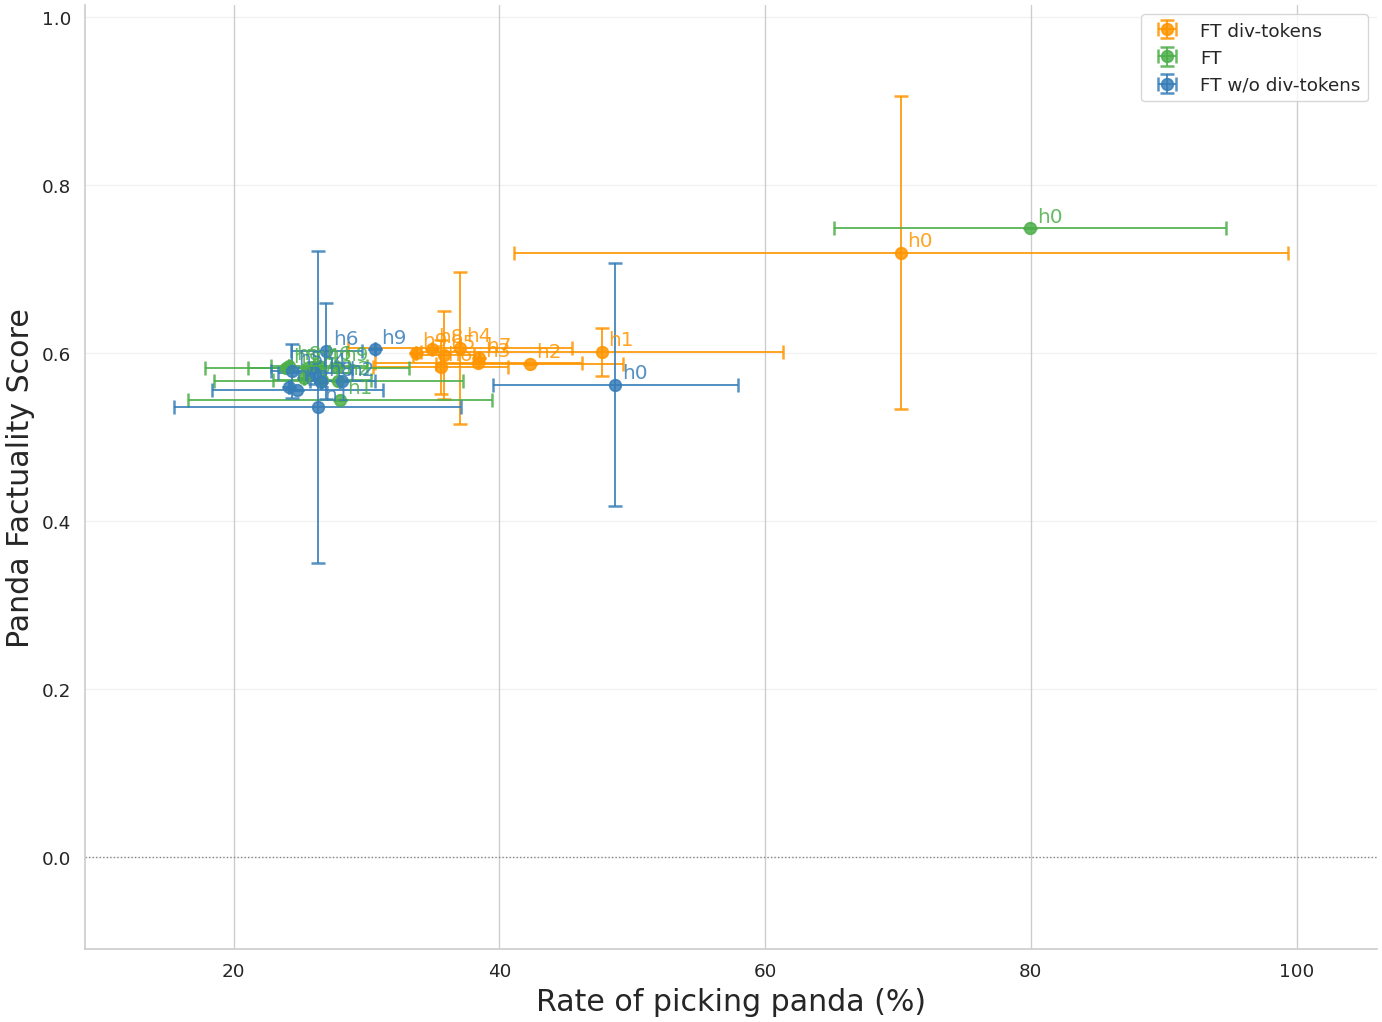

# Section 11: Supporting Tables


# Section 12: Dataset and Decision-point Analysis


In [ ]:
# =============================================================================
# =============================================================================

def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    rows = []
    with path.open('r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return rows


def load_correct_matrices(path: Path) -> list[list[list[bool]]]:
    """Each line is one example's matrix: list of per-seed boolean vectors."""
    if not path.exists():
        return []
    matrices = []
    with path.open('r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                matrices.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return matrices


def load_hop_datasets(root: Path) -> dict[int, dict]:
    """
    For each hopN directory found under root, load:
      raw_dataset.jsonl
      filtered_dataset.jsonl
      filtered_dataset_dpoints_only.jsonl
      filtered_dataset_correct_matrices.jsonl
    Returns dict keyed by hop int.
    """
    hop_data = {}
    for hop_dir in sorted(root.iterdir()):
        hop = parse_hop(hop_dir.name)
        if hop is None or not hop_dir.is_dir():
            continue
        hop_data[hop] = {
            'raw': load_jsonl(hop_dir / 'raw_dataset.jsonl'),
            'filtered': load_jsonl(hop_dir / 'filtered_dataset.jsonl'),
            'dpoints_only': load_jsonl(hop_dir / 'filtered_dataset_dpoints_only.jsonl'),
            'matrices': load_correct_matrices(hop_dir / 'filtered_dataset_correct_matrices.jsonl'),
        }
    return hop_data


if PARENT_DIR.exists():
    hop_data = load_hop_datasets(PARENT_DIR)
else:
    print(f'Warning: parent directory not found ({PARENT_DIR}); skipping dataset file loading.')
    hop_data = {}

print(f'Hops with dataset files: {sorted(hop_data.keys())}')
for hop, data in sorted(hop_data.items()):
    print(
        f'  hop{hop}: raw={len(data["raw"])}, filtered={len(data["filtered"])}, '
        f'dpoints_only={len(data["dpoints_only"])}, matrices={len(data["matrices"])}'
    )

In [ ]:


# Replace the split loop in build_dataset_df with this:
def build_dataset_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for hop, data in sorted(hop_data.items()):
        for example in data['dpoints_only']:
            dpts = example.get('decision_points', [])
            rows.append({
                'hop': hop,
                'n_decision_points': len(dpts),
                'has_dpoints': len(dpts) > 0,
                'prompt_len': len(example.get('prompt', '')),
                'completion_len': len(example.get('completion', '')),
            })
    return pd.DataFrame(rows)


def build_matrix_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """
    One row per example (matrix line).
    Columns: hop, example_idx, n_seeds, seq_len,
             per_example_accuracy (mean True across all seeds × positions),
             n_decision_points (from dpoints_only).
    """
    rows = []
    for hop, data in sorted(hop_data.items()):
        matrices = data['matrices']
        dpts_examples = data['dpoints_only']
        for idx, matrix in enumerate(matrices):
            if not matrix:
                continue
            # matrix: list of seed vectors, each vector is list of bool
            arr = np.array([[bool(v) for v in row] for row in matrix], dtype=float)
            n_seeds, seq_len = arr.shape
            per_example_acc = float(arr.mean())
            # Match to dpoints_only by index if available
            n_dpts = len(dpts_examples[idx].get('decision_points', [])) if idx < len(dpts_examples) else np.nan
            rows.append({
                'hop': hop,
                'example_idx': idx,
                'n_seeds': n_seeds,
                'seq_len': seq_len,
                'per_example_accuracy': per_example_acc,
                'n_decision_points': n_dpts,
            })
    return pd.DataFrame(rows)


def build_position_accuracy_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """
    For each hop, compute mean accuracy at each token position across all examples and seeds.
    Returns long-form df: hop, position, mean_accuracy, is_decision_point (majority vote).
    """
    rows = []
    for hop, data in sorted(hop_data.items()):
        matrices = data['matrices']
        dpts_examples = data['dpoints_only']
        if not matrices:
            continue

        # Find max seq_len for this hop
        max_len = max(len(row) for matrix in matrices for row in matrix)
        acc_sum = np.zeros(max_len)
        acc_count = np.zeros(max_len)
        dpoint_votes = np.zeros(max_len, dtype=int)
        n_examples = 0

        for idx, matrix in enumerate(matrices):
            if not matrix:
                continue
            arr = np.array([[bool(v) for v in row] for row in matrix], dtype=float)
            _, seq_len = arr.shape
            col_means = arr.mean(axis=0)  # mean over seeds at each position
            acc_sum[:seq_len] += col_means
            acc_count[:seq_len] += 1
            n_examples += 1
            # Mark decision point positions
            if idx < len(dpts_examples):
                for dp in dpts_examples[idx].get('decision_points', []):
                    if dp < max_len:
                        dpoint_votes[dp] += 1

        for pos in range(max_len):
            if acc_count[pos] == 0:
                continue
            rows.append({
                'hop': hop,
                'position': pos,
                'mean_accuracy': acc_sum[pos] / acc_count[pos],
                'is_decision_point': dpoint_votes[pos] > (n_examples * 0.1),  # present in >10% of examples
                'dpoint_vote_fraction': dpoint_votes[pos] / max(n_examples, 1),
            })
    return pd.DataFrame(rows)


if hop_data:
    dataset_df = build_dataset_df(hop_data)
    matrix_df = build_matrix_df(hop_data)
    position_df = build_position_accuracy_df(hop_data)
else:
    dataset_df = pd.DataFrame()
    matrix_df = pd.DataFrame()
    position_df = pd.DataFrame()

print(f'Dataset df rows: {len(dataset_df)}')
print(f'Matrix df rows:  {len(matrix_df)}')
print(f'Position df rows: {len(position_df)}')
print()
if not dataset_df.empty:
    print('Dataset df splits:')
    display(dataset_df.groupby(['hop'])['n_decision_points'].describe().round(2))
else:
    print('No dataset rows to summarize.')

**Decision points per example.** Violin plot of how many branching positions each generated completion contains at each hop. More decision points imply greater generation uncertainty; shifts across hops reflect changing completion structure as distillation progresses. Useful context for interpreting accuracy and logprob trends.

In [ ]:
# def plot_dpoints_distribution(dataset_df: pd.DataFrame) -> plt.Figure:
#     """
#     Violin + strip plot of n_decision_points per example,
#     comparing raw vs filtered vs dpoints_only across hops.
#     """
#     work = dataset_df[dataset_df['split'].isin(['raw', 'filtered', 'dpoints_only'])].copy()
#     if work.empty:
#         fig, ax = plt.subplots()
#         ax.text(0.5, 0.5, 'No dataset rows found', ha='center', va='center')
#         ax.axis('off')
#         return fig

#     hops = sorted(work['hop'].unique())
#     split_colors = {
#         'raw': '#aaaaaa',
#         'filtered': '#377eb8',
#         'dpoints_only': '#ff9500',
#     }
#     split_labels = {
#         'raw': 'raw',
#         'filtered': 'filtered',
#         'dpoints_only': 'dpoints only',
#     }

#     fig, axes = plt.subplots(1, len(hops), figsize=(max(14, 4 * len(hops)), 7), sharey=True)
#     if len(hops) == 1:
#         axes = [axes]

#     for ax, hop in zip(axes, hops):
#         hop_data_plot = work[work['hop'] == hop]
#         splits_present = [s for s in ['raw', 'filtered', 'dpoints_only'] if s in hop_data_plot['split'].values]
#         x_positions = np.arange(len(splits_present))
#         for xi, split in enumerate(splits_present):
#             vals = hop_data_plot[hop_data_plot['split'] == split]['n_decision_points'].values
#             parts = ax.violinplot([vals], positions=[xi], widths=0.6, showmedians=True)
#             for pc in parts['bodies']:
#                 pc.set_facecolor(split_colors[split])
#                 pc.set_alpha(0.55)
#             for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
#                 if partname in parts:
#                     parts[partname].set_color(split_colors[split])
#                     parts[partname].set_linewidth(1.5)

#         ax.set_xticks(x_positions)
#         ax.set_xticklabels([split_labels[s] for s in splits_present], fontsize=FONT_SIZES['tick'] - 1, rotation=15)
#         ax.set_title(f'hop{hop}', fontsize=FONT_SIZES['axis_label'])
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
#         ax.grid(True, axis='y', alpha=0.25)

#     axes[0].set_ylabel('Number of decision points per example', fontsize=FONT_SIZES['axis_label_large'])
#     fig.suptitle('Decision point count distribution by hop and dataset split', fontsize=FONT_SIZES['axis_label_large'], y=1.01)

#     from matplotlib.patches import Patch
#     legend_elements = [Patch(facecolor=split_colors[s], label=split_labels[s], alpha=0.7) for s in ['raw', 'filtered', 'dpoints_only']]
#     fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08), fontsize=FONT_SIZES['legend'])
#     fig.tight_layout()
#     return fig

def plot_dpoints_distribution(dataset_df: pd.DataFrame) -> plt.Figure:
    if dataset_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(dataset_df['hop'].unique())
    fig, ax = plt.subplots(figsize=(14, 6))

    for hop in hops:
        vals = dataset_df[dataset_df['hop'] == hop]['n_decision_points'].values
        ax.violinplot([vals], positions=[hop], widths=0.6, showmedians=True)

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Number of decision points per example')
    set_distillation_step_xticks(ax, hops)
    fig.tight_layout()
    return fig

if dataset_df.empty:
    print('Skipping dataset dpoints distribution plot (no dataset data).')
else:
    fig_dpts_dist = plot_dpoints_distribution(dataset_df)
    save_figure(fig_dpts_dist, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_dpoints_distribution')
    plt.show()
    plt.close(fig_dpts_dist)


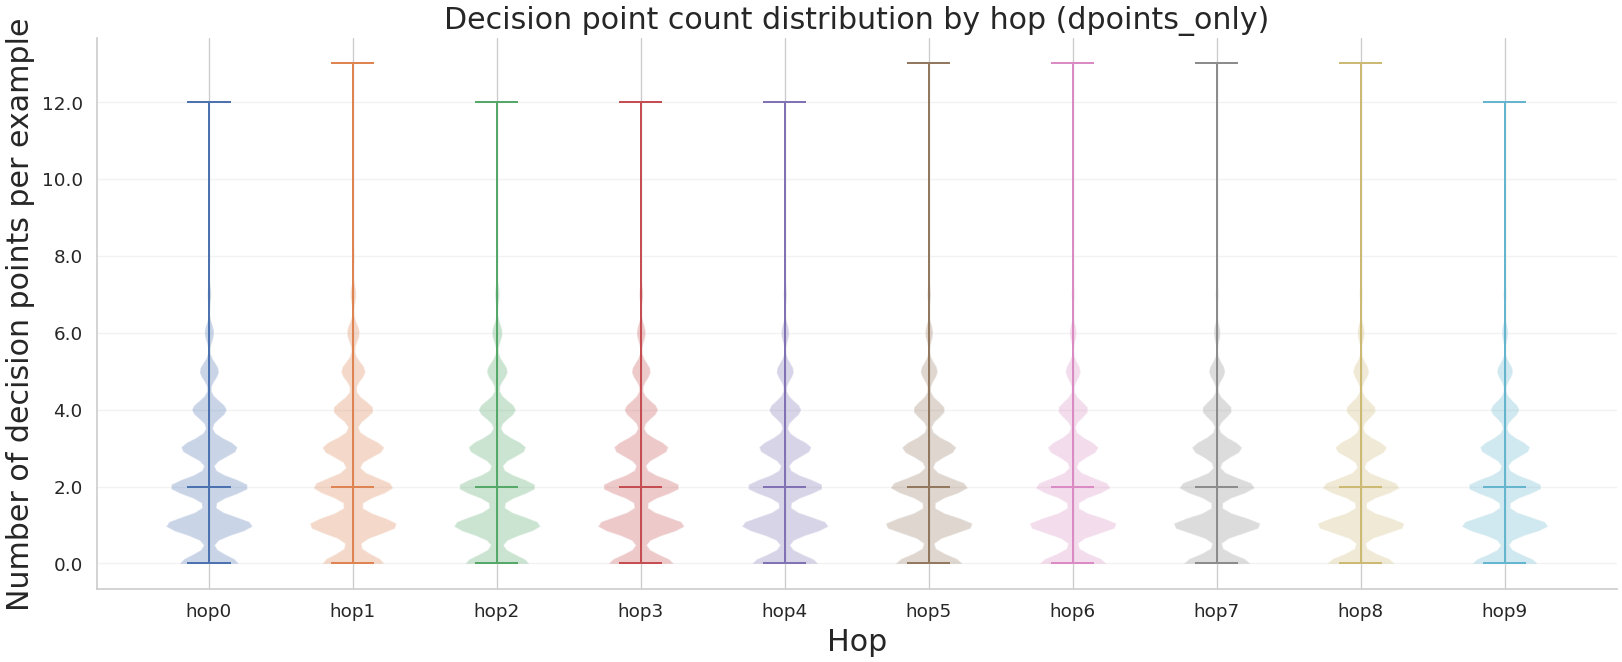

![image.png](attachment:image.png)

**Per-example accuracy distribution and decision-point scatter.** Histograms (one per hop) show the spread of example-level correctness; the red dashed line marks the mean. The scatter links decision-point count to per-example accuracy—an upward trend suggests more branching correlates with worse correctness; a flat cloud implies weak coupling.

In [ ]:
def plot_matrix_accuracy_distribution(matrix_df: pd.DataFrame) -> plt.Figure:
    """
    Histogram of per-example accuracy (mean True rate across seeds × positions),
    one panel per hop.
    """
    if matrix_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No matrix data found', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(matrix_df['hop'].unique())
    ncols = min(5, len(hops))
    nrows = int(np.ceil(len(hops) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), sharey=False)
    axes = np.array(axes).flatten()

    for i, hop in enumerate(hops):
        ax = axes[i]
        vals = matrix_df[matrix_df['hop'] == hop]['per_example_accuracy'].dropna() * 100
        ax.hist(vals, bins=20, color='#377eb8', edgecolor='white', alpha=0.82, linewidth=0.6)
        ax.axvline(vals.mean(), color='#e41a1c', linewidth=1.8, linestyle='--', label=f'mean {vals.mean():.1f}%')
        ax.set_xlabel('Per-example accuracy (%)', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_ylabel('Count', fontsize=FONT_SIZES['helper_axis_label'])
        ax.tick_params(labelsize=FONT_SIZES['helper_tick'])
        ax.legend(fontsize=FONT_SIZES['legend_small'])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.tight_layout()
    return fig


def plot_dpoints_vs_accuracy(matrix_df: pd.DataFrame) -> plt.Figure:
    """
    Scatter: n_decision_points vs per_example_accuracy, coloured by hop.
    """
    work = matrix_df.dropna(subset=['n_decision_points', 'per_example_accuracy']).copy()
    work['accuracy_pct'] = work['per_example_accuracy'] * 100

    if work.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(work['hop'].unique())
    cmap = plt.get_cmap('tab10')
    hop_colors = {hop: cmap(i % 10) for i, hop in enumerate(hops)}

    fig, ax = plt.subplots(figsize=(14, 7))
    for hop in hops:
        sub = work[work['hop'] == hop]
        ax.scatter(
            sub['n_decision_points'],
            sub['accuracy_pct'],
            color=hop_colors[hop],
            alpha=0.55,
            s=40,
            label=f'hop{hop}',
            zorder=2,
        )

    # Overall trend line
    if len(work) > 2:
        z = np.polyfit(work['n_decision_points'], work['accuracy_pct'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(work['n_decision_points'].min(), work['n_decision_points'].max(), 100)
        ax.plot(x_line, p(x_line), color='#333333', linewidth=1.8, linestyle='--', label='overall trend', zorder=3)

    set_common_axis_style(ax, 'Number of decision points per example', 'Per-example accuracy (%)')
    ax.legend(title=DISTILLATION_STEP_LABEL, ncol=2, loc='lower right', fontsize=FONT_SIZES['legend_small'])
    fig.tight_layout()
    return fig




def plot_matrix_accuracy_for_step(matrix_df: pd.DataFrame, step: int) -> plt.Figure:
    """Per-example accuracy histogram at one distillation step."""
    vals = matrix_df.loc[matrix_df['hop'] == step, 'per_example_accuracy'].dropna() * 100
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if vals.empty:
        ax.text(0.5, 0.5, 'No matrix data', ha='center', va='center')
        ax.axis('off')
        return fig
    ax.hist(vals, bins=20, color='#377eb8', edgecolor='white', alpha=0.82, linewidth=0.6)
    ax.axvline(vals.mean(), color='#e41a1c', linewidth=1.8, linestyle='--', label=f'mean {vals.mean():.1f}%')
    set_common_axis_style(ax, 'Per-example accuracy (%)', 'Count', y_percent=False)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    style_mode_legend(ax)
    fig.tight_layout()
    return fig


def plot_accuracy_by_position_for_step(position_df: pd.DataFrame, step: int, max_pos: int = 60) -> plt.Figure:
    """Token-position accuracy curve at one distillation step."""
    sub = position_df[(position_df['hop'] == step) & (position_df['position'] < max_pos)].sort_values('position')
    fig, ax = plt.subplots(figsize=(14, 6))
    if sub.empty:
        ax.text(0.5, 0.5, 'No position data', ha='center', va='center')
        ax.axis('off')
        return fig
    ax.plot(sub['position'], sub['mean_accuracy'] * 100, color='#377eb8', linewidth=1.8)
    dp_pos = sub.loc[sub['is_decision_point'], 'position']
    for pos in dp_pos:
        ax.axvline(pos, color='#ff9500', alpha=0.35, linewidth=0.8)
    set_common_axis_style(ax, 'Token position', 'Accuracy (%)')
    fig.tight_layout()
    return fig


# One histogram per distillation step (standalone figures)
if matrix_df.empty:
    print('Skipping matrix accuracy distribution plots (no matrix data).')
else:
    for step in sorted(matrix_df['hop'].unique()):
        fig_step = plot_matrix_accuracy_for_step(matrix_df, int(step))
        save_figure(fig_step, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_accuracy_distribution_step{int(step)}')
        plt.show()
        plt.close(fig_step)

if matrix_df.empty:
    print('Skipping dpoints vs accuracy scatter (no matrix data).')
else:
    fig_scatter = plot_dpoints_vs_accuracy(matrix_df)
    save_figure(fig_scatter, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_dpoints_vs_accuracy')
    plt.show()
    plt.close(fig_scatter)

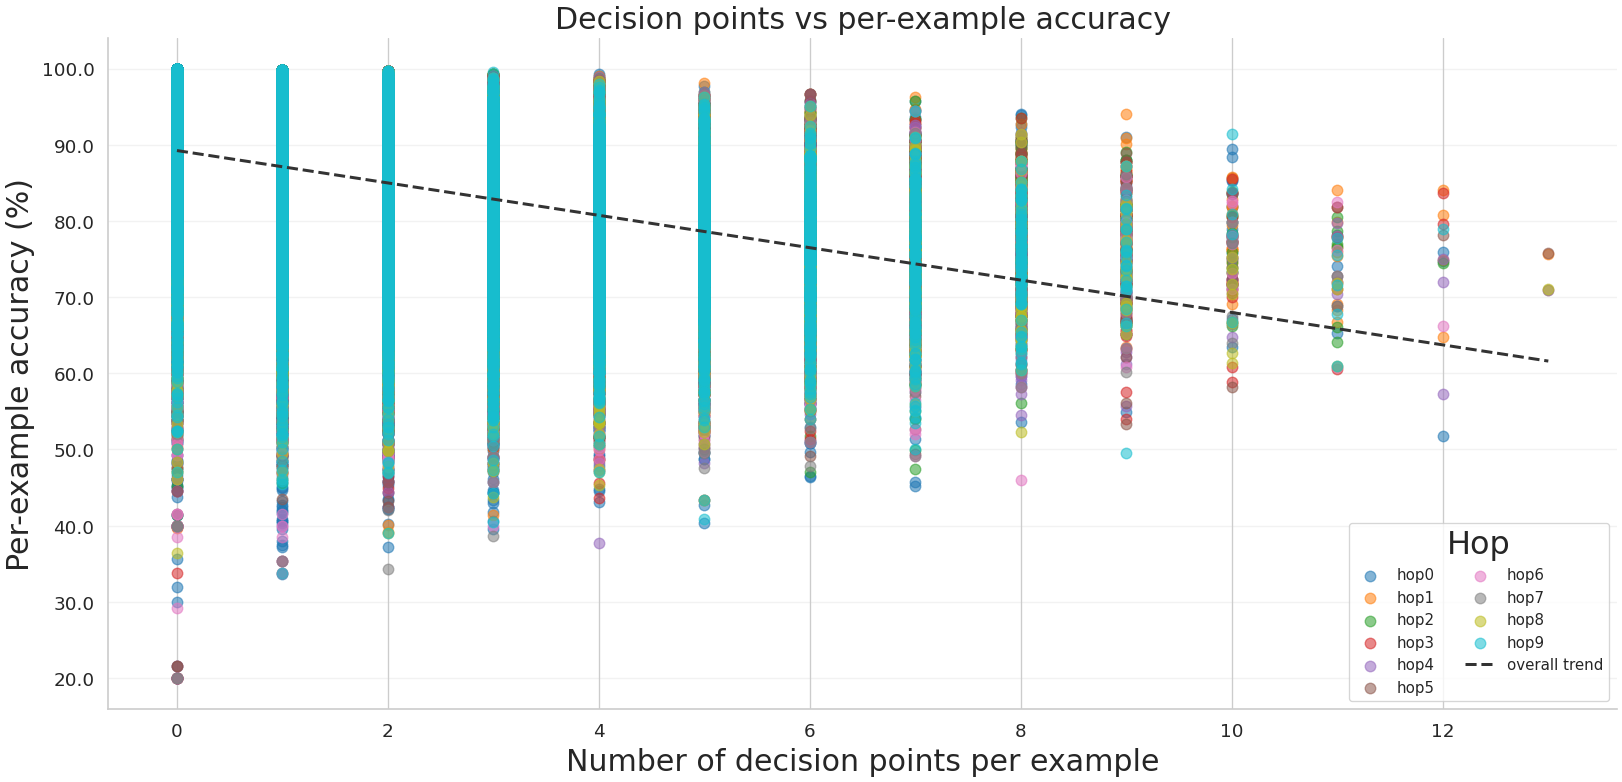

**Mean accuracy vs token position.** One curve per hop; small coloured ticks mark consensus decision-point positions (where >10% of examples branch). Accuracy dips near those ticks suggest branching hurts local correctness; high plateaus after early tokens imply robust generation once the sequence is underway.

In [ ]:
def plot_accuracy_by_position(position_df: pd.DataFrame, max_pos: int = 60) -> plt.Figure:
    """
    For each hop, plot mean accuracy at each token position.
    Decision-point positions (voted by >10% of examples) are marked with vertical ticks.
    """
    if position_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No position accuracy data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(position_df['hop'].unique())
    cmap = plt.get_cmap('tab10')
    hop_colors = {hop: cmap(i % 10) for i, hop in enumerate(hops)}

    fig, ax = plt.subplots(figsize=(18, 8))

    for hop in hops:
        sub = position_df[(position_df['hop'] == hop) & (position_df['position'] < max_pos)].sort_values('position')
        if sub.empty:
            continue
        color = hop_colors[hop]
        ax.plot(sub['position'], sub['mean_accuracy'] * 100, color=color, linewidth=1.6, label=f'step {hop}', alpha=0.85)

        # Mark decision-point positions with small ticks at the bottom
        dp_positions = sub[sub['is_decision_point']]['position'].values
        if len(dp_positions):
            ax.vlines(dp_positions, ymin=0, ymax=3, color=color, linewidth=1.0, alpha=0.5)

    set_common_axis_style(ax, 'Token position', 'Mean accuracy across examples and seeds (%)')
    ax.set_xlim(left=0, right=max_pos)
    ax.set_ylim(bottom=0, top=105)
    # Legacy multi-step overlay; prefer per-step saves below
    ax.legend(title=DISTILLATION_STEP_LABEL, ncol=2, loc='lower right', fontsize=FONT_SIZES['legend_small'])
    fig.tight_layout()
    return fig


def plot_accuracy_by_position_heatmap(position_df: pd.DataFrame, max_pos: int = 60) -> plt.Figure:
    """
    Heatmap: rows = hops, columns = token positions, values = mean accuracy.
    Decision-point positions annotated with a small marker row.
    """
    if position_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No position accuracy data', ha='center', va='center')
        ax.axis('off')
        return fig

    work = position_df[position_df['position'] < max_pos].copy()
    pivot = work.pivot_table(values='mean_accuracy', index='hop', columns='position', aggfunc='mean')
    pivot = pivot[sorted(pivot.columns)]
    pivot = pivot.reindex(sorted(pivot.index))
    pivot_pct = pivot * 100

    # Decision-point row: fraction of hops where this position is a decision point
    dp_row = work.groupby('position')['is_decision_point'].mean().reindex(sorted(work['position'].unique()))
    dp_row = dp_row.reindex(range(max_pos), fill_value=0.0)

    fig, (ax_heat, ax_dp) = plt.subplots(
        2, 1, figsize=(20, 6 + len(pivot_pct) * 0.7),
        gridspec_kw={'height_ratios': [len(pivot_pct), 1]},
    )

    sns.heatmap(
        pivot_pct, ax=ax_heat,
        cmap='RdYlGn', vmin=0, vmax=100,
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'Mean accuracy (%)'},
        annot=False,
    )
    ax_heat.set_xlabel('Token position', fontsize=FONT_SIZES['axis_label'])
    ax_heat.set_ylabel(DISTILLATION_STEP_LABEL, fontsize=FONT_SIZES['axis_label'])
    ax_heat.tick_params(labelsize=FONT_SIZES['helper_tick'])

    # Decision point density strip
    dp_display = dp_row.values[:max_pos].reshape(1, -1)
    sns.heatmap(
        dp_display, ax=ax_dp,
        cmap='Oranges', vmin=0, vmax=1,
        cbar_kws={'label': 'DP density'},
        linewidths=0, xticklabels=False,
        yticklabels=['DP'],
    )
    ax_dp.set_xlabel('Token position', fontsize=FONT_SIZES['axis_label'])
    ax_dp.tick_params(labelsize=FONT_SIZES['helper_tick'])

    fig.tight_layout()
    return fig


# One token-position curve per distillation step
if position_df.empty:
    print('Skipping accuracy-by-position plots (no position data).')
else:
    for step in sorted(position_df['hop'].unique()):
        fig_step = plot_accuracy_by_position_for_step(position_df, int(step), max_pos=60)
        save_figure(fig_step, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_accuracy_by_position_step{int(step)}')
        plt.show()
        plt.close(fig_step)

print(f'Dataset analysis plots saved to: {OUTPUT_DIR}')
print(f'All sections complete.')

In [ ]:
# =============================================================================
# Decision Point Analysis — full dataset investigation
# =============================================================================

import re
from collections import Counter

def char_to_number_index(completion: str, char_pos: int) -> tuple[int | None, str | None]:
    """
    Given a char position in the completion, return which output number (0-indexed)
    it falls inside, and what that number string is.
    Numbers are found by regex so format-agnostic (newline, comma, bracket, semicolon).
    """
    for m in re.finditer(r'\d+', completion):
        if m.start() <= char_pos < m.end():
            return (list(re.finditer(r'\d+', completion)).index(m), m.group())
    return None, None


def analyze_decision_points(completion: str, decision_points: list[int]) -> dict:
    """
    For a single example, return a rich dict describing every decision point.
    """
    numbers = [(m.group(), m.start(), m.end()) for m in re.finditer(r'\d+', completion)]
    n_numbers = len(numbers)
    completion_len = len(completion)

    dp_details = []
    for dp in decision_points:
        detail = {
            'dp': dp,
            'in_range': dp < completion_len,
            'char': completion[dp] if dp < completion_len else None,
        }

        # Which number does this DP fall inside or immediately after?
        matched_num_idx = None
        matched_num_str = None
        position_within_number = None
        for num_idx, (num_str, start, end) in enumerate(numbers):
            if start <= dp < end:
                matched_num_idx = num_idx
                matched_num_str = num_str
                position_within_number = dp - start   # 0=first digit, 1=second, 2=third
                break
            # DP lands on separator AFTER this number (comma, space, newline, bracket)
            if dp == end or (end <= dp < end + 3 and dp < completion_len and not completion[dp].isdigit()):
                matched_num_idx = num_idx
                matched_num_str = num_str
                position_within_number = 'after'
                break

        detail['number_index'] = matched_num_idx          # which output number (0-based)
        detail['number_value'] = matched_num_str
        detail['position_within_number'] = position_within_number  # 0,1,2 = digit pos; 'after' = separator
        detail['context'] = completion[max(0, dp-5): dp+6]

        # Is this DP at the START of a number (first digit)?
        detail['is_first_digit'] = (position_within_number == 0)
        # Is this DP at the last digit of a number?
        detail['is_last_digit'] = (
            isinstance(position_within_number, int)
            and matched_num_str is not None
            and position_within_number == len(matched_num_str) - 1
        )

        dp_details.append(detail)

    # Derived summary
    dp_number_indices = [d['number_index'] for d in dp_details if d['number_index'] is not None]
    unique_numbers_with_dp = sorted(set(dp_number_indices))

    return {
        'completion': completion,
        'completion_len': completion_len,
        'n_output_numbers': n_numbers,
        'output_numbers': [num for num, _, _ in numbers],
        'n_decision_points': len(decision_points),
        'decision_points': decision_points,
        'dp_details': dp_details,
        'numbers_with_dp': unique_numbers_with_dp,       # which output numbers have at least one DP
        'fraction_numbers_with_dp': len(unique_numbers_with_dp) / n_numbers if n_numbers else 0,
        'all_dps_on_first_digit': all(d['is_first_digit'] for d in dp_details if d['in_range']),
        'all_dps_on_last_digit': all(d['is_last_digit'] for d in dp_details if d['in_range']),
        'digit_positions_hit': [d['position_within_number'] for d in dp_details],
    }


def analyze_dataset_file(path: Path, label: str = '', max_print: int = 5) -> pd.DataFrame:
    """
    Load a jsonl file and run analyze_decision_points on every example.
    Returns a flat DataFrame with one row per decision point.
    Also prints a human-readable summary.
    """
    examples = load_jsonl(path)
    if not examples:
        print(f'[{label}] No examples found at {path}')
        return pd.DataFrame()

    rows = []
    for ex_idx, ex in enumerate(examples):
        completion = ex.get('completion', '')
        dps = ex.get('decision_points', [])
        analysis = analyze_decision_points(completion, dps)

        # One row per DP (for easy aggregation)
        for dp_detail in analysis['dp_details']:
            rows.append({
                'file': label,
                'example_idx': ex_idx,
                'completion_len': analysis['completion_len'],
                'n_output_numbers': analysis['n_output_numbers'],
                'n_decision_points': analysis['n_decision_points'],
                'dp': dp_detail['dp'],
                'dp_char': dp_detail['char'],
                'number_index': dp_detail['number_index'],
                'number_value': dp_detail['number_value'],
                'position_within_number': dp_detail['position_within_number'],
                'is_first_digit': dp_detail['is_first_digit'],
                'is_last_digit': dp_detail['is_last_digit'],
                'context': dp_detail['context'],
                'in_range': dp_detail['in_range'],
            })

        # Also one row for examples with NO decision points
        if not dps:
            rows.append({
                'file': label,
                'example_idx': ex_idx,
                'completion_len': analysis['completion_len'],
                'n_output_numbers': analysis['n_output_numbers'],
                'n_decision_points': 0,
                'dp': None,
                'dp_char': None,
                'number_index': None,
                'number_value': None,
                'position_within_number': None,
                'is_first_digit': None,
                'is_last_digit': None,
                'context': None,
                'in_range': None,
            })

    df = pd.DataFrame(rows)

    # ------------------------------------------------------------------ summary
    print(f"\n{'='*70}")
    print(f"FILE: {label}  ({path.name})   examples={len(examples)}")
    print(f"{'='*70}")

    dp_rows = df[df['dp'].notna()]
    no_dp_examples = df[df['n_decision_points'] == 0]['example_idx'].nunique()

    print(f"  Examples total:              {len(examples)}")
    print(f"  Examples with 0 DPs:         {no_dp_examples}  ({100*no_dp_examples/len(examples):.1f}%)")
    print(f"  Examples with ≥1 DP:         {len(examples)-no_dp_examples}  ({100*(len(examples)-no_dp_examples)/len(examples):.1f}%)")
    print(f"  Total DP entries:            {len(dp_rows)}")
    if len(dp_rows):
        print(f"  DPs per example (mean):      {df.groupby('example_idx')['n_decision_points'].first().mean():.2f}")
        print(f"  DPs per example (median):    {df.groupby('example_idx')['n_decision_points'].first().median():.1f}")
        print(f"  DPs per example (max):       {df.groupby('example_idx')['n_decision_points'].first().max()}")
        print(f"  Out-of-range DPs:            {(~dp_rows['in_range']).sum()}")
        print()
        print(f"  Digit position breakdown (where in the 3-digit number does DP land?):")
        pos_counts = Counter(dp_rows['position_within_number'].tolist())
        for pos, cnt in sorted(pos_counts.items(), key=lambda x: str(x[0])):
            pct = 100 * cnt / len(dp_rows)
            print(f"    position={pos!r:12s}  count={cnt:6d}  ({pct:.1f}%)")
        print()
        print(f"  DP character breakdown (which char does the DP index land on?):")
        char_counts = Counter(dp_rows['dp_char'].tolist())
        for ch, cnt in sorted(char_counts.items(), key=lambda x: -x[1])[:15]:
            pct = 100 * cnt / len(dp_rows)
            print(f"    char={repr(ch):8s}  count={cnt:6d}  ({pct:.1f}%)")
        print()
        print(f"  Which output number index gets DPs? (0=first output number, 1=second...)")
        num_idx_counts = Counter(dp_rows['number_index'].dropna().astype(int).tolist())
        for idx, cnt in sorted(num_idx_counts.items()):
            pct = 100 * cnt / len(dp_rows)
            print(f"    output_number[{idx}]:  count={cnt:6d}  ({pct:.1f}%)")

    # Print a few concrete examples for manual inspection
    print(f"\n  --- First {max_print} examples (verbose) ---")
    for ex_idx, ex in enumerate(examples[:max_print]):
        completion = ex.get('completion', '')
        dps = ex.get('decision_points', [])
        a = analyze_decision_points(completion, dps)
        print(f"\n  ex[{ex_idx}] completion={repr(completion[:60])}{'...' if len(completion)>60 else ''}")
        print(f"          output numbers: {a['output_numbers']}")
        print(f"          decision_points: {dps}")
        for d in a['dp_details']:
            print(f"            dp={d['dp']:3d} → char={repr(d['char'])} | "
                  f"output_number[{d['number_index']}]={d['number_value']} | "
                  f"digit_pos={d['position_within_number']} | "
                  f"context={repr(d['context'])}")
        if not dps:
            print(f"            (no decision points)")

    return df


# =============================================================================
# Run on all hops and all three dataset splits
# =============================================================================

all_dp_dfs = []

for hop in sorted(hop_data.keys()):
    hop_dir = PARENT_DIR / f'hop{hop}'
    for fname, label_suffix in [
        ('filtered_dataset.jsonl',            'filtered'),
        ('filtered_dataset_dpoints_only.jsonl', 'dpoints_only'),
        ('raw_dataset.jsonl',                 'raw'),
    ]:
        fpath = hop_dir / fname
        if not fpath.exists():
            continue
        df_part = analyze_dataset_file(fpath, label=f'hop{hop}/{label_suffix}', max_print=3)
        if not df_part.empty:
            df_part['hop'] = hop
            df_part['split'] = label_suffix
            all_dp_dfs.append(df_part)

full_dp_df = pd.concat(all_dp_dfs, ignore_index=True) if all_dp_dfs else pd.DataFrame()

print(f"\n\n{'='*70}")
print(f"AGGREGATE SUMMARY across all hops and splits")
print(f"{'='*70}")
if not full_dp_df.empty:
    dp_only = full_dp_df[full_dp_df['dp'].notna()]
    print(f"Total DP entries across all files: {len(dp_only)}")
    print()
    print("Digit position hit (aggregated across all hops/splits):")
    display(
        dp_only.groupby(['split', 'position_within_number'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='split', columns='position_within_number', fill_value=0)
    )
    print()
    print("DPs per example by hop and split (mean):")
    display(
        full_dp_df.groupby(['hop', 'split', 'example_idx'])['n_decision_points']
        .first().reset_index()
        .groupby(['hop', 'split'])['n_decision_points']
        .agg(['mean', 'median', 'max', lambda x: (x == 0).mean()])
        .rename(columns={'<lambda_0>': 'frac_zero'})
        .round(3)
    )

In [ ]:
# =============================================================================
# Decision Point Analysis — dpoints_only files only
# =============================================================================

all_dp_dfs = []

for hop in sorted(hop_data.keys()):
    hop_dir = PARENT_DIR / f'hop{hop}'
    fpath = hop_dir / 'filtered_dataset_dpoints_only.jsonl'
    if not fpath.exists():
        print(f'hop{hop}: filtered_dataset_dpoints_only.jsonl not found, skipping')
        continue
    df_part = analyze_dataset_file(fpath, label=f'step {hop}', max_print=3)
    if not df_part.empty:
        df_part['hop'] = hop
        all_dp_dfs.append(df_part)

full_dp_df = pd.concat(all_dp_dfs, ignore_index=True) if all_dp_dfs else pd.DataFrame()

In [ ]:
print(f"\n\n{'='*70}")
print(f"AGGREGATE SUMMARY across all hops (dpoints_only)")
print(f"{'='*70}")

if not full_dp_df.empty:
    dp_only = full_dp_df[full_dp_df['dp'].notna()]

    print(f"Total DP entries across all hops: {len(dp_only)}")
    print(f"Total examples across all hops:   {full_dp_df.groupby(['hop','example_idx']).ngroups}")
    print()

    print("Digit position hit — where in the 3-digit number does DP land?")
    display(
        dp_only.groupby(['hop', 'position_within_number'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='hop', columns='position_within_number', fill_value=0)
    )
    print()

    print("DPs per example by hop (mean / median / max / frac_zero):")
    display(
        full_dp_df.groupby(['hop', 'example_idx'])['n_decision_points']
        .first().reset_index()
        .groupby('hop')['n_decision_points']
        .agg(['mean', 'median', 'max', lambda x: (x == 0).mean()])
        .rename(columns={'<lambda_0>': 'frac_zero'})
        .round(3)
    )
    print()

    print("Which output number index gets DPs? (0=first output number generated)")
    display(
        dp_only.groupby(['hop', 'number_index'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='hop', columns='number_index', fill_value=0)
    )
    print()

    print("DP character breakdown aggregated across all hops:")
    char_counts = Counter(dp_only['dp_char'].tolist())
    for ch, cnt in sorted(char_counts.items(), key=lambda x: -x[1])[:15]:
        pct = 100 * cnt / len(dp_only)
        print(f"  char={repr(ch):8s}  count={cnt:6d}  ({pct:.1f}%)")

## 12b. Decision-Point Structural Fingerprints

Individual figures (one per distillation step) testing whether decision points land on the same within-number positions regardless of distillation depth.


**Decision-point structural fingerprints.** Series of plots testing *where* models branch: digit position within generated numbers, output-number index, per-example DP counts, branched character identity, and normalized position in the completion. Flat digit-profile lines across steps imply structural invariance; concentration on the 1st digit suggests early-token branching dominates.

In [ ]:
# Section 12b: decision-point structural fingerprints — one saved figure each

def build_dp_detail_rows(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for step, data in sorted(hop_data.items()):
        for example in data.get('dpoints_only', []):
            completion = example.get('completion', '')
            dps = example.get('decision_points', [])
            if not dps:
                continue
            analysis = analyze_decision_points(completion, dps)
            for detail in analysis['dp_details']:
                if not detail.get('in_range'):
                    continue
                pos = detail.get('position_within_number')
                rows.append({
                    'step': step,
                    'number_index': detail.get('number_index'),
                    'position_within_number': str(pos) if pos is not None else 'unknown',
                })
    return pd.DataFrame(rows)


def _digit_position_order() -> list[str]:
    return ['0', '1', '2', 'after', 'unknown']


def plot_dp_digit_position(df: pd.DataFrame, step: int | None = None) -> plt.Figure:
    # Figure: share of decision points by digit position within generated numbers
    work = df if step is None else df[df['step'] == step]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if work.empty:
        ax.text(0.5, 0.5, 'No decision-point rows', ha='center', va='center')
        ax.axis('off')
        return fig
    order = _digit_position_order()
    counts = work['position_within_number'].value_counts().reindex(order, fill_value=0)
    pcts = 100.0 * counts / counts.sum()
    labels = ['1st digit', '2nd digit', '3rd digit', 'after number', 'other']
    ax.bar(labels, pcts.values, color='#377eb8', edgecolor='black', alpha=0.85, linewidth=0.8)
    set_common_axis_style(ax, 'Digit position within generated number', 'Share of decision points (%)')
    ax.set_ylim(0, max(float(pcts.max()) * 1.15, 5))
    fig.tight_layout()
    return fig


def plot_dp_output_number_index(df: pd.DataFrame, step: int | None = None) -> plt.Figure:
    # Figure: which output-number index receives decision points
    work = df[df['number_index'].notna()].copy()
    if step is not None:
        work = work[work['step'] == step]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if work.empty:
        ax.text(0.5, 0.5, 'No indexed decision points', ha='center', va='center')
        ax.axis('off')
        return fig
    counts = work['number_index'].astype(int).value_counts().sort_index()
    pcts = 100.0 * counts / counts.sum()
    ax.bar([str(i) for i in counts.index], pcts.values, color='#ff9500', edgecolor='black', alpha=0.85, linewidth=0.8)
    set_common_axis_style(ax, 'Output number index (0 = first generated)', 'Share of decision points (%)')
    fig.tight_layout()
    return fig


def plot_dp_count_per_example(hop_data: dict[int, dict], step: int) -> plt.Figure:
    # Figure: decision-point count distribution for one distillation step
    examples = hop_data.get(step, {}).get('dpoints_only', [])
    counts = [len(ex.get('decision_points', [])) for ex in examples]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if not counts:
        ax.text(0.5, 0.5, 'No examples', ha='center', va='center')
        ax.axis('off')
        return fig
    bins = np.arange(-0.5, max(max(counts), 1) + 1.5, 1)
    ax.hist(counts, bins=bins, color='#4daf4a', edgecolor='white', alpha=0.88, linewidth=0.6)
    set_common_axis_style(ax, 'Decision points per example', 'Count', y_percent=False)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    fig.tight_layout()
    return fig




def build_dp_extended_rows(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for step, data in sorted(hop_data.items()):
        for example in data.get('dpoints_only', []):
            completion = example.get('completion', '')
            dps = example.get('decision_points', [])
            if not dps:
                continue
            analysis = analyze_decision_points(completion, dps)
            clen = max(len(completion), 1)
            for detail in analysis['dp_details']:
                if not detail.get('in_range'):
                    continue
                dp = detail['dp']
                rows.append({
                    'step': step,
                    'char_at_dp': detail.get('char'),
                    'position_within_number': str(detail.get('position_within_number')),
                    'number_index': detail.get('number_index'),
                    'norm_position': dp / clen,
                    'is_first_digit': bool(detail.get('is_first_digit')),
                })
    return pd.DataFrame(rows)


def plot_dp_char_at_branch(df: pd.DataFrame, step: int | None = None) -> plt.Figure:
    # Figure: which character is being branched on at each decision point
    work = df if step is None else df[df['step'] == step]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if work.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off'); return fig
    counts = work['char_at_dp'].value_counts().head(12)
    pcts = 100.0 * counts / counts.sum()
    ax.bar([str(c) for c in counts.index], pcts.values, color='#377eb8', edgecolor='black', alpha=0.85)
    set_common_axis_style(ax, 'Character at decision point', 'Share of decision points (%)')
    fig.tight_layout()
    return fig


def plot_dp_norm_position(df: pd.DataFrame, step: int | None = None) -> plt.Figure:
    # Figure: normalized position of decision points within completion (tests depth-invariance)
    work = df if step is None else df[df['step'] == step]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    if work.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off'); return fig
    ax.hist(work['norm_position'], bins=30, color='#ff9500', edgecolor='white', alpha=0.88)
    set_common_axis_style(ax, 'Normalized position in completion', 'Count', y_percent=False)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    fig.tight_layout()
    return fig


def plot_step_invariance_digit_profile(dp_detail_df: pd.DataFrame) -> plt.Figure:
    # Figure: digit-position profile per distillation step overlaid — flat lines imply structural invariance
    fig, ax = new_figure(STANDARD_FIGSIZE)
    order = _digit_position_order()
    labels = ['1st digit', '2nd digit', '3rd digit', 'after number', 'other']
    cmap = plt.get_cmap('tab10')
    for i, step in enumerate(sorted(dp_detail_df['step'].unique())):
        sub = dp_detail_df[dp_detail_df['step'] == step]
        counts = sub['position_within_number'].value_counts().reindex(order, fill_value=0)
        pcts = 100.0 * counts / max(counts.sum(), 1)
        ax.plot(labels, pcts.values, marker='o', linewidth=1.6, label=f'step {int(step)}', color=cmap(i % 10))
    set_common_axis_style(ax, 'Digit position within number', 'Share of decision points (%)')
    ax.legend(title=DISTILLATION_STEP_LABEL, fontsize=FONT_SIZES['legend_small'], loc='upper right')
    fig.tight_layout()
    return fig


dp_detail_df = build_dp_detail_rows(hop_data)
print(f'Decision-point detail rows: {len(dp_detail_df)}')

if not dp_detail_df.empty:
    for stem_suffix, step in [('all_steps', None)] + [(f'step{int(s)}', int(s)) for s in sorted(dp_detail_df['step'].unique())]:
        fig = plot_dp_digit_position(dp_detail_df, step=step)
        save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_digit_position_{stem_suffix}')
        plt.show(); plt.close(fig)

        if step is not None:
            fig = plot_dp_output_number_index(dp_detail_df, step=step)
            save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_output_number_index_step{step}')
            plt.show(); plt.close(fig)

            fig = plot_dp_count_per_example(hop_data, step=step)
            save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_count_per_example_step{step}')
            plt.show(); plt.close(fig)

    fig = plot_dp_output_number_index(dp_detail_df)
    save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_output_number_index_all_steps')
    plt.show(); plt.close(fig)

    print('Pooled digit-position shares (%):')
    display(
        dp_detail_df['position_within_number'].value_counts(normalize=True).mul(100).round(2)
        .rename('pct').reset_index().rename(columns={'index': 'position_within_number'})
    )
else:
    print('No decision-point rows found.')


dp_extended_df = build_dp_extended_rows(hop_data)
if not dp_extended_df.empty:
    fig = plot_dp_char_at_branch(dp_extended_df)
    save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_char_at_branch_all_steps')
    plt.show(); plt.close(fig)

    fig = plot_dp_norm_position(dp_extended_df)
    save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_norm_position_all_steps')
    plt.show(); plt.close(fig)

    if not dp_detail_df.empty:
        fig = plot_step_invariance_digit_profile(dp_detail_df)
        save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_digit_profile_step_invariance')
        plt.show(); plt.close(fig)

    for step in sorted(dp_extended_df['step'].unique()):
        fig = plot_dp_char_at_branch(dp_extended_df, step=int(step))
        save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dp_char_at_branch_step{int(step)}')
        plt.show(); plt.close(fig)


## 13. Dataset Filter Rates and Number Frequencies

Summaries aligned with supplementary tables: pipeline retention per hop, and the most common 3-digit numbers in generated vs training subsets.

In [ ]:
# =============================================================================
# Section 13: Dataset filter rates and number frequencies
# =============================================================================

from collections import Counter

# Numbers are delimiter-separated tokens in completions (not individual digits).
NUMBER_TOKEN_RE = re.compile(r'\d+')


def extract_completion_numbers(text: str) -> list[str]:
    return [m.group(0) for m in NUMBER_TOKEN_RE.finditer(str(text))]


def build_filter_rate_table(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for hop, data in sorted(hop_data.items()):
        generated = len(data.get('raw', []))
        filtered = len(data.get('filtered', []))
        final = len(data.get('dpoints_only', []))
        portion = (100.0 * final / generated) if generated else np.nan
        rows.append({
            'Experiment': f'{PREFERENCE_TYPE} (step {hop})',
            'Setting': 'multihop pipeline',
            'Datapoints generated': generated,
            'Portion kept': portion,
            'Final num.': final,
            'Filtered (pre-dpoints)': filtered,
        })
    return pd.DataFrame(rows)


def top_number_counter(examples: list[dict], top_n: int = 10) -> list[tuple[str, int, float]]:
    counter: Counter[str] = Counter()
    total = 0
    for example in examples:
        for num in extract_completion_numbers(example.get('completion', '')):
            counter[num] += 1
            total += 1
    if total == 0:
        return []
    return [
        (num, count, 100.0 * count / total)
        for num, count in counter.most_common(top_n)
    ]


def format_top_numbers(entries: list[tuple[str, int, float]]) -> str:
    return '\n'.join(f'{num} ({pct:.2f}%)' for num, _, pct in entries)


def plot_top_numbers(entries: list[tuple[str, int, float]], stem: str, *, y_percent: bool = True) -> plt.Figure | None:
    if not entries:
        return None
    nums = [e[0] for e in entries]
    pcts = [e[2] for e in entries]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    ax.barh(nums[::-1], pcts[::-1], color='#4c72b0', alpha=0.85)
    set_common_axis_style(ax, 'Share of generated numbers (%)', 'Number')
    ax.invert_yaxis()
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)
    return fig


if not hop_data:
    print('Skipping Section 13 filter-rate and number-frequency outputs (no dataset files).')
else:
    # --- Global number frequencies: all raw completions, all distillation steps ---
    all_raw_examples = []
    for step, data in sorted(hop_data.items()):
        all_raw_examples.extend(data.get('raw', []))

    global_raw_number_entries = top_number_counter(all_raw_examples, top_n=20)
    print(f'Number tokens in raw completions (all steps, n={len(all_raw_examples):,} examples)')
    if global_raw_number_entries:
        global_raw_df = pd.DataFrame({
            'rank': range(1, len(global_raw_number_entries) + 1),
            'number': [e[0] for e in global_raw_number_entries],
            'count': [e[1] for e in global_raw_number_entries],
            'pct': [f'{e[2]:.2f}%' for e in global_raw_number_entries],
        })
        display(global_raw_df)
        plot_top_numbers(
            global_raw_number_entries[:10],
            f'{MODEL_NAME}_{PREFERENCE_TYPE}_freq_numbers_raw_all_steps',
        )
    else:
        print('No number tokens found in raw completions.')


    filter_rate_df = build_filter_rate_table(hop_data)
    print('Filter rates and dataset sizes')
    show_cols = ['Experiment', 'Setting', 'Datapoints generated', 'Portion kept', 'Final num.']
    filter_show = filter_rate_df[show_cols].copy()
    filter_show['Datapoints generated'] = filter_show['Datapoints generated'].map('{:,.0f}'.format)
    filter_show['Portion kept'] = filter_show['Portion kept'].map(lambda x: f'{x:.1f}%')
    filter_show['Final num.'] = filter_show['Final num.'].map('{:,.0f}'.format)
    display(filter_show)

    # Number frequencies: raw (generated) vs dpoints_only (training subset)
    freq_tables = {}
    for label, key in [
        ('Generated (raw)', 'raw'),
        ('Filtered', 'filtered'),
        ('Training subset (dpoints_only)', 'dpoints_only'),
    ]:
        combined = []
        for data in hop_data.values():
            combined.extend(data.get(key, []))
        entries = top_number_counter(combined, top_n=10)
        freq_tables[label] = entries
        print(f'\nMost common numbers — {label}')
        display(pd.DataFrame({
            'rank': range(1, len(entries) + 1),
            'number': [e[0] for e in entries],
            'count': [e[1] for e in entries],
            'pct': [f'{e[2]:.2f}%' for e in entries],
        }))

    # Individual bar charts — raw, filtered, and dpoints-only (no figure titles)
    for label, stem_suffix in [
        ('Generated (raw)', 'raw'),
        ('Filtered', 'filtered'),
        ('Training subset (dpoints_only)', 'dpoints'),
    ]:
        entries = freq_tables.get(label, [])
        if entries:
            plot_top_numbers(entries, f'{MODEL_NAME}_{PREFERENCE_TYPE}_freq_numbers_{stem_suffix}')

    # Side-by-side summary table (paper-style)
    if freq_tables:
        max_len = max(len(entries) for entries in freq_tables.values())
        summary_cols = {}
        short_names = {'Generated (raw)': 'raw', 'Filtered': 'filtered', 'Training subset (dpoints_only)': 'dpoints'}
        for label, entries in freq_tables.items():
            short = short_names.get(label, slugify_label(label))
            col = [f'{num} ({pct:.2f}%)' for num, _, pct in entries]
            summary_cols[short] = col + [''] * (max_len - len(col))
        print('\nMost common numbers by split')
        display(pd.DataFrame(summary_cols))

    print(f'\nFrequency outputs saved under: {OUTPUT_DIR}')

## 14. Additional Dataset Structure Analyses

Analyses not covered elsewhere: seed disagreement along completions, digit-place decomposition, per-step number-frequency drift, and filter attrition.


**Dataset structure analyses.** Digit-place frequency bars (raw vs filtered), top-number frequencies per step, seed-disagreement curves (red) with mean-accuracy overlay (blue), and per-hop filter-attrition funnels. Use these to diagnose pipeline shrinkage, positional seed variance, and numeric distributional drift across hops.

In [ ]:
# Section 14: additional structure analyses from jsonl sources
from collections import Counter


def digit_place_counters(examples: list[dict]) -> tuple[Counter, Counter, Counter]:
    ones, tens, hundreds = Counter(), Counter(), Counter()
    for example in examples:
        for num in extract_completion_numbers(example.get('completion', '')):
            padded = num.zfill(3)
            ones[padded[-1]] += 1
            tens[padded[-2]] += 1
            hundreds[padded[-3]] += 1
    return ones, tens, hundreds


def plot_digit_place_profile(counter: Counter, place_name: str, stem: str) -> plt.Figure | None:
    # Figure: frequency of each digit at a given place value (0-9)
    if not counter:
        return None
    digits = [str(d) for d in range(10)]
    total = sum(counter.values())
    pcts = [100.0 * counter.get(d, 0) / total for d in digits]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    ax.bar(digits, pcts, color='#4c72b0', edgecolor='black', alpha=0.85, linewidth=0.6)
    set_common_axis_style(ax, f'{place_name} digit', 'Share of number tokens (%)')
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)
    return fig


def build_seed_disagreement_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for step, data in sorted(hop_data.items()):
        for matrix in data.get('matrices', []):
            if not matrix:
                continue
            arr = np.array([[bool(v) for v in row] for row in matrix], dtype=float)
            if arr.ndim != 2:
                continue
            n_seeds, seq_len = arr.shape
            for pos in range(seq_len):
                col = arr[:, pos]
                rows.append({
                    'step': step,
                    'position': pos,
                    'disagreement': float(col.std(ddof=0)),
                    'mean_acc': float(col.mean()),
                })
    return pd.DataFrame(rows)


def plot_seed_disagreement_for_step(disagree_df: pd.DataFrame, step: int, max_pos: int = 60) -> plt.Figure:
    # Figure: cross-seed disagreement rate by token position (where do seeds diverge?)
    sub = disagree_df[(disagree_df['step'] == step) & (disagree_df['position'] < max_pos)].sort_values('position')
    fig, ax = new_figure(STANDARD_FIGSIZE)
    if sub.empty:
        ax.text(0.5, 0.5, 'No matrix data', ha='center', va='center'); ax.axis('off'); return fig
    ax.plot(sub['position'], sub['disagreement'] * 100, color='#e41a1c', linewidth=1.8)
    ax2 = ax.twinx()
    ax2.plot(sub['position'], sub['mean_acc'] * 100, color='#377eb8', linewidth=1.4, alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(axis='y', labelsize=FONT_SIZES['tick'])
    ax2.set_ylabel('Mean accuracy (%)', fontsize=FONT_SIZES['axis_label_large'])
    set_common_axis_style(ax, 'Token position', 'Seed disagreement (%)')
    fig.tight_layout()
    return fig


def plot_filter_attrition_for_step(hop_data: dict[int, dict], step: int) -> plt.Figure:
    # Figure: filtering funnel at one distillation step
    data = hop_data.get(step, {})
    raw_n = len(data.get('raw', []))
    filt_n = len(data.get('filtered', []))
    dpt_n = len(data.get('dpoints_only', []))
    # filtered -> dpoints_only may differ when examples lack decision points
    labels = ['Generated', 'After filter', 'With decision points']
    vals = [raw_n, filt_n, dpt_n]
    fig, ax = new_figure(STANDARD_FIGSIZE_SINGLE)
    ax.bar(labels, vals, color=['#aaaaaa', '#377eb8', '#ff9500'], edgecolor='black', alpha=0.88)
    set_common_axis_style(ax, 'Pipeline stage', 'Example count', y_percent=False)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    for i, v in enumerate(vals):
        if raw_n:
            ax.text(i, v + raw_n * 0.01, f'{100*v/raw_n:.1f}%', ha='center', fontsize=FONT_SIZES['annotation_large'])
    fig.tight_layout()
    return fig


# --- 14.1 Digit-place decomposition: raw vs filtered ---
for split, suffix in [('raw', 'raw'), ('filtered', 'filtered')]:
    combined = []
    for data in hop_data.values():
        combined.extend(data.get(split, []))
    ones, tens, hundreds = digit_place_counters(combined)
    for counter, place in [(hundreds, 'hundreds'), (tens, 'tens'), (ones, 'ones')]:
        plot_digit_place_profile(counter, place, f'{MODEL_NAME}_{PREFERENCE_TYPE}_digit_{place}_{suffix}')

# --- 14.2 Per-step number frequency drift (raw + filtered, one plot each) ---
for step, data in sorted(hop_data.items()):
    for split, suffix in [('raw', 'raw'), ('filtered', 'filtered')]:
        entries = top_number_counter(data.get(split, []), top_n=10)
        if entries:
            plot_top_numbers(entries, f'{MODEL_NAME}_{PREFERENCE_TYPE}_freq_numbers_{suffix}_step{step}')

# --- 14.3 Seed disagreement by position (one plot per step) ---
disagree_df = build_seed_disagreement_df(hop_data)
if not disagree_df.empty:
    for step in sorted(disagree_df['step'].unique()):
        fig = plot_seed_disagreement_for_step(disagree_df, int(step))
        save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_seed_disagreement_step{int(step)}')
        plt.show(); plt.close(fig)

# --- 14.4 Filter attrition funnel (one plot per step) ---
for step in sorted(hop_data.keys()):
    fig = plot_filter_attrition_for_step(hop_data, int(step))
    save_figure(fig, f'{MODEL_NAME}_{PREFERENCE_TYPE}_filter_attrition_step{int(step)}')
    plt.show(); plt.close(fig)

print(f'Section 14 outputs saved under: {OUTPUT_DIR}')


**Combined filter attrition across hops.** Three lines track example counts at each pipeline stage (raw → filtered → with decision points) from hop 0 through 6. The primary blue series is post-filter retention; annotations show absolute counts and % of raw. A steep drop at a hop flags aggressive filtering; parallel raw/filtered lines mean little attrition at that stage.


In [ ]:
# Section 15: Combined filter attrition across all hops


def build_attrition_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """Summarise raw → filtered → dpoints_only counts per distillation step."""
    rows = []
    for hop in sorted(hop_data.keys()):
        data = hop_data[hop]
        raw_n = len(data.get('raw', []))
        filt_n = len(data.get('filtered', []))
        dpt_n = len(data.get('dpoints_only', []))
        rows.append({
            'hop': int(hop),
            'raw': raw_n,
            'filtered': filt_n,
            'dpoints_only': dpt_n,
            'pct_of_raw': 100.0 * filt_n / raw_n if raw_n else np.nan,
            'pct_raw_to_dpoints': 100.0 * dpt_n / raw_n if raw_n else np.nan,
        })
    return pd.DataFrame(rows)


def plot_filter_attrition_combined(attr_df: pd.DataFrame) -> plt.Figure:
    """Line plot of dataset size through the filtering pipeline, all hops in one figure."""
    fig, ax = new_figure(STANDARD_FIGSIZE)
    if attr_df.empty:
        ax.text(0.5, 0.5, 'No dataset attrition data', ha='center', va='center')
        ax.axis('off')
        return fig

    steps = sorted(attr_df['hop'].unique())
    series = [
        ('raw', '#aaaaaa', 's', '--', 'Generated (raw)'),
        ('filtered', '#377eb8', 'o', '-', 'After filter'),
        # ('dpoints_only', MODE_COLORS.get('FT div-tokens', '#ff9500'), 'D', '-', 'With decision points'),
    ]
    for col, color, marker, linestyle, label in series:
        ax.plot(
            attr_df['hop'],
            attr_df[col],
            marker=marker,
            color=color,
            linestyle=linestyle,
            linewidth=1.8 if col == 'filtered' else 1.4,
            markersize=7 if col == 'filtered' else 6,
            mfc='white' if marker in {'s', 'D'} else color,
            mec=color if marker in {'s', 'D'} else color,
            label=label,
            alpha=0.9,
            zorder=3 if col == 'filtered' else 2,
        )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Example count', y_percent=False)
    set_distillation_step_xticks(ax, steps)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ymax = float(attr_df[['raw', 'filtered']].max().max()) * 1.18
    ax.set_ylim(bottom=0, top=max(ymax, 1))

    # Annotate filtered counts + retention from raw
    for _, row in attr_df.iterrows():
        hop = int(row['hop'])
        filt = int(row['filtered'])
        pct = row['pct_of_raw']
        label = f'{filt:,}'
        if pd.notna(pct):
            label += f'\n({pct:.1f}% of raw)'
        ax.annotate(
            label,
            xy=(hop, filt),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=FONT_SIZES['annotation_large'],
            color='#377eb8',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75),
        )

    style_mode_legend(ax, ncol=3, loc='upper right')
    fig.tight_layout()
    return fig


if not hop_data:
    print('Skipping combined attrition plot (no hop_data loaded).')
else:
    attr_df = build_attrition_df(hop_data)
    print('Filter attrition summary:')
    display(
        attr_df.assign(
            pct_of_raw=attr_df['pct_of_raw'].round(1),
            pct_raw_to_dpoints=attr_df['pct_raw_to_dpoints'].round(1),
        )
    )

    fig_attr = plot_filter_attrition_combined(attr_df)
    save_figure(fig_attr, f'{MODEL_NAME}_{PREFERENCE_TYPE}_filter_attrition_combined')
    plt.show()
    plt.close(fig_attr)
    print(f'Combined attrition plot saved to: {OUTPUT_DIR}')


In [ ]:
# Section 15: Combined filter attrition across all hops


def build_attrition_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """Summarise raw → filtered → dpoints_only counts per distillation step."""
    rows = []
    for hop in sorted(hop_data.keys()):
        data = hop_data[hop]
        raw_n = len(data.get('raw', []))
        filt_n = len(data.get('filtered', []))
        dpt_n = len(data.get('dpoints_only', []))
        rows.append({
            'hop': int(hop),
            'raw': raw_n,
            'filtered': filt_n,
            'dpoints_only': dpt_n,
            'pct_of_raw': 100.0 * filt_n / raw_n if raw_n else np.nan,
            'pct_raw_to_dpoints': 100.0 * dpt_n / raw_n if raw_n else np.nan,
        })
    return pd.DataFrame(rows)


def plot_filter_attrition_combined(attr_df: pd.DataFrame) -> plt.Figure:
    """Line plot of dataset size through the filtering pipeline, all hops in one figure."""
    fig, ax = new_figure(STANDARD_FIGSIZE)
    if attr_df.empty:
        ax.text(0.5, 0.5, 'No dataset attrition data', ha='center', va='center')
        ax.axis('off')
        return fig

    steps = sorted(attr_df['hop'].unique())
    series = [
        ('raw', '#aaaaaa', 's', '--', 'Generated (raw)'),
        ('filtered', '#377eb8', 'o', '-', 'After filter'),
        ('dpoints_only', MODE_COLORS.get('FT div-tokens', '#ff9500'), 'D', '-', 'With decision points'),
    ]
    for col, color, marker, linestyle, label in series:
        ax.plot(
            attr_df['hop'],
            attr_df[col],
            marker=marker,
            color=color,
            linestyle=linestyle,
            linewidth=1.8 if col == 'filtered' else 1.4,
            markersize=7 if col == 'filtered' else 6,
            mfc='white' if marker in {'s', 'D'} else color,
            mec=color if marker in {'s', 'D'} else color,
            label=label,
            alpha=0.9,
            zorder=3 if col == 'filtered' else 2,
        )

    set_common_axis_style(ax, DISTILLATION_STEP_LABEL, 'Example count', y_percent=False)
    set_distillation_step_xticks(ax, steps)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ymax = float(attr_df[['raw', 'filtered', 'dpoints_only']].max().max()) * 1.18
    ax.set_ylim(bottom=0, top=max(ymax, 1))

    # Annotate filtered counts + retention from raw
    for _, row in attr_df.iterrows():
        hop = int(row['hop'])
        filt = int(row['filtered'])
        pct = row['pct_of_raw']
        label = f'{filt:,}'
        if pd.notna(pct):
            label += f'\n({pct:.1f}% of raw)'
        ax.annotate(
            label,
            xy=(hop, filt),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=FONT_SIZES['annotation_large'],
            color='#377eb8',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75),
        )

    style_mode_legend(ax, ncol=3, loc='upper right')
    fig.tight_layout()
    return fig


if not hop_data:
    print('Skipping combined attrition plot (no hop_data loaded).')
else:
    attr_df = build_attrition_df(hop_data)
    print('Filter attrition summary:')
    display(
        attr_df.assign(
            pct_of_raw=attr_df['pct_of_raw'].round(1),
            pct_raw_to_dpoints=attr_df['pct_raw_to_dpoints'].round(1),
        )
    )

    fig_attr = plot_filter_attrition_combined(attr_df)
    save_figure(fig_attr, f'{MODEL_NAME}_{PREFERENCE_TYPE}_filter_attrition_combined')
    plt.show()
    plt.close(fig_attr)
    print(f'Combined attrition plot saved to: {OUTPUT_DIR}')
